# Laboratorio 7 — NLP end-to-end y Embeddings

**CC3092 Deep Learning y Sistemas Inteligentes** · Fernando Andree Hernández Martínez (23645) · Fernando José Rueda Rodas (23748)

Se construye un pipeline de NLP completo, **texto crudo → tokens → IDs → vectores → modelo → salida**:

1. Exploración y preprocesamiento de **WikiText-103** (normalización, tokenizador propio, ley de Zipf, vocabulario, submuestreo y pares skip-gram).
2. Investigación de `nn.Embedding`, `nn.EmbeddingBag` y de los modelos Word2Vec / GloVe.
3. Tres conjuntos de embeddings: **SGNS propio en PyTorch**, **Word2Vec de gensim** sobre el mismo corpus y **GloVe 6B-100d** preentrenado.
4. Verificación de la aritmética vectorial (analogías individuales, benchmark por categoría con 3CosAdd/3CosMul, t-SNE y paralelismo de vectores diferencia).
5. Clasificación de **AG News** con TF-IDF, embeddings aleatorios y embeddings preentrenados (congelados y con fine-tuning).

El código reutilizable vive en `src/` (`text.py`, `sgns.py`, `evaluation.py`, `classify.py`, `plots.py`); el notebook lo orquesta y discute los resultados.

In [1]:
import sys, json, platform, random, subprocess, time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from IPython.display import display, Image

import src.config as C
from src import text as T, sgns as S, evaluation as E, classify as K, plots as P

random.seed(C.SEED); np.random.seed(C.SEED); torch.manual_seed(C.SEED)
pd.set_option("display.max_colwidth", 120); pd.set_option("display.width", 200)
P.set_style()
DEVICE = S.get_device()
chip = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True).stdout.strip()
print("PyTorch", torch.__version__, "| dispositivo:", DEVICE, "|", chip or platform.processor(), "|", platform.platform())
import gensim, datasets, spacy, nltk, sklearn
print("gensim", gensim.__version__, "| datasets", datasets.__version__, "| spaCy", spacy.__version__,
      "| NLTK", nltk.__version__, "| scikit-learn", sklearn.__version__)

PyTorch 2.14.1 | dispositivo: mps | Apple M4 Pro | macOS-27.0.1-arm64-arm-64bit


gensim 4.4.0 | datasets 5.0.1 | spaCy 3.8.16 | NLTK 3.10.3 | scikit-learn 1.9.1


**Hardware.** Todo se ejecutó en un Apple **M4 Pro** (CPU de 14 núcleos, GPU integrada de 20 núcleos, 24 GB de memoria unificada). El SGNS propio se entrena en la GPU con el backend **MPS** de PyTorch; no hay CUDA, así que la memoria pico se mide muestreando `torch.mps.current_allocated_memory()` (en CUDA sería `torch.cuda.max_memory_allocated()`). Word2Vec de gensim corre en CPU con 12 hilos y los clasificadores de AG News en CPU (son modelos pequeños y la latencia de lanzar kernels en MPS no compensa).

## 1. Datos

| Recurso | Fuente | Uso |
|---|---|---|
| WikiText-103 (raw) | `load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")` | Corpus para entrenar los embeddings (split `train`) |
| AG News | `load_dataset("fancyzhx/ag_news")` | Clasificación de noticias en 4 clases |
| GloVe 6B-100d | `gensim.downloader.load("glove-wiki-gigaword-100")` | Embeddings preentrenados de referencia (Wikipedia 2014 + Gigaword 5, 6B tokens, 400k palabras) |
| `questions-words.txt` | `gensim.test.utils.datapath` | 19,544 analogías en 14 categorías (selección de modelos) |
| `wordsim353.tsv` | idem | 353 pares con similitud humana (selección de modelos) |
| `simlex999.txt` | idem | 999 pares, reservado para la evaluación final |

Los datos se descargan en `data/raw/` (no versionado) la primera vez; el corpus tokenizado se cachea en `data/processed/`.

## 2. Exploración y preprocesamiento del texto

### 2.1 Tamaño del corpus

WikiText-103 viene como una lista de líneas: títulos de artículo (` = Título = `), subtítulos (` = = Sección = = `), párrafos y líneas vacías. Un **artículo** empieza en un título de nivel 1 rodeado de líneas vacías (hay líneas de tablas con el mismo formato, p. ej. ` = Goals ; A = `, que no son títulos). Los **tokens** se cuentan de dos formas: separando por espacios el texto original (la cuenta oficial, que incluye puntuación) y con nuestro tokenizador (sin puntuación, ver 2.2).

In [2]:
from datasets import load_dataset
wiki = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
stats, corpus = T.prepare_wikitext()      # escaneo completo del train + subconjunto en IDs (cacheado)

rows = []
for split in ["train", "validation", "test"]:
    lines = wiki[split]["text"]
    kinds = pd.Series(T.classify_lines(lines)).value_counts()
    raw_tokens = sum(len(l.split()) for l in lines)
    ours = int(stats["tokens_per_line"].sum()) if split == "train" else \
        sum(len(T.tokenize(l)) for l, k in zip(lines, T.classify_lines(lines)) if k == "text")
    rows.append({"split": split, "artículos": kinds.get("article", 0), "líneas (filas)": len(lines),
                 "párrafos de texto": kinds.get("text", 0), "subtítulos": kinds.get("heading", 0),
                 "líneas vacías": kinds.get("empty", 0), "tokens (split por espacios)": raw_tokens,
                 "tokens (nuestro tokenizador)": ours})
size = pd.DataFrame(rows).set_index("split")
display(size.style.format("{:,}"))
print(f"Vocabulario del train completo con nuestro tokenizador: {len(stats['counter']):,} tipos")

,artículos,líneas (filas),párrafos de texto,subtítulos,líneas vacías,tokens (split por espacios),tokens (nuestro tokenizador)
split,,,,,,,
train,"28,472","1,801,350","860,934","275,623","636,321","101,425,671","84,614,118"
validation,60,"3,760","1,841",560,"1,299","213,886","179,562"
test,60,"4,358","2,187",644,"1,467","241,211","201,732"


Vocabulario del train completo con nuestro tokenizador: 716,855 tipos


**¿Cuántos artículos, líneas y tokens tiene el corpus?** El split de entrenamiento tiene **28,472 artículos** y **1,801,350 líneas** (860,934 párrafos de texto, 275,623 subtítulos y 636,321 líneas vacías). Separando por espacios hay **101.4M tokens** (la cifra oficial de 103.2M cuenta además un token de fin de línea por cada una de las 1.8M líneas); con nuestro tokenizador, que descarta la puntuación y reúne `role @-@ playing` en un token, quedan **84.6M tokens** y **716,855 tipos**. Validación y test son mucho más pequeños (60 artículos cada uno, ~0.2M tokens). Para entrenar usamos un **subconjunto de 25.0M tokens** (los primeros 8,478 artículos completos), por encima del mínimo de 20M que pide el laboratorio, para poder hacer 13 iteraciones en tiempo razonable.

### 2.2 Normalización

Las decisiones se tomaron para que el vocabulario sea **compatible con el de GloVe 6B** (tokenizado con el tokenizador de Stanford, todo en minúsculas), de modo que una palabra signifique lo mismo en los tres modelos y la comparación sea justa:

| Decisión | Qué hacemos | Por qué |
|---|---|---|
| Minúsculas | todo a minúsculas | GloVe 6B es *uncased*; si no, `France` y `france` serían palabras distintas y las preguntas de analogía (en mayúsculas) no coincidirían. |
| Separadores de WikiText | ` @-@ ` → `-`, ` @,@ ` → `,`, ` @.@ ` → `.` | WikiText parte `role-playing` y `102,779`; GloVe tiene `role-playing`, `e-mail`, `3.5` como un solo token. |
| Clíticos | `don't` → `do n't`, `game's` → `game 's` | Es la convención Penn Treebank que usa GloVe (`n't` y `'s` son tokens de su vocabulario). WikiText ya viene así; AG News no, así que se aplica la misma regla a ambos. |
| Acrónimos | `U.S.` → `u.s.` (se conserva el punto interno) | GloVe tiene `u.s.` como token frecuente. |
| Puntuación | se descarta | No aporta a las relaciones semánticas de los benchmarks y, al ser lo más frecuente, solo ocuparía ventanas de contexto. |
| Números | se conservan como tokens (`1990`, `1990s`, `3.5`, `1,000`) | GloVe tiene vectores para números; reemplazarlos por `<num>` crearía un token que GloVe no tiene. |
| Artefactos de AG News | `\`, `#39;`, `&lt;b&gt;`, etiquetas HTML | Restos del scraping (`#39;` es un apóstrofo escapado). |
| Tokens especiales | `<unk>` (palabras con frecuencia < `min_count`) y `<pad>` (relleno en el clasificador) | Ver 2.5. En SGNS las palabras fuera del vocabulario se **eliminan** del flujo antes de formar ventanas, igual que hacen word2vec y gensim. |

Las ventanas de contexto no cruzan párrafos ni artículos. Los títulos y subtítulos se descartan (son estructura, no prosa).

In [3]:
ejemplos = [
    " It is a tactical role @-@ playing game that sold 102 @,@ 779 units at 3 @.@ 5 dollars . \n",
    "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
    "Google #39;s IPO: &lt;b&gt;Analysts&lt;/b&gt; don't expect the U.S. market to crash.",
]
for e in ejemplos:
    print("crudo      :", repr(e))
    print("normalizado:", T.normalize(e))
    print("tokens     :", T.tokenize(e), "\n")

crudo      : ' It is a tactical role @-@ playing game that sold 102 @,@ 779 units at 3 @.@ 5 dollars . \n'
normalizado: it is a tactical role-playing game that sold 102,779 units at 3.5 dollars .
tokens     : ['it', 'is', 'a', 'tactical', 'role-playing', 'game', 'that', 'sold', '102,779', 'units', 'at', '3.5', 'dollars'] 

crudo      : "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."
normalizado: wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street 's dwindling band of ultra-cynics, are seeing green again.
tokens     : ['wall', 'st', 'bears', 'claw', 'back', 'into', 'the', 'black', 'reuters', 'reuters', 'short-sellers', 'wall', 'street', "'s", 'dwindling', 'band', 'of', 'ultra-cynics', 'are', 'seeing', 'green', 'again'] 

crudo      : "Google #39;s IPO: &lt;b&gt;Analysts&lt;/b&gt; don't expect the U.S. market to crash."
normalizado: google 's ipo: analyst

### 2.3 Tokenizador propio contra spaCy y NLTK

Nuestro tokenizador es una expresión regular sobre el texto normalizado (`src/text.py`): acrónimos con punto, clíticos, números con formato y palabras con guion o apóstrofo internos. Se compara con `spaCy` (`en_core_web_sm`, solo el tokenizador) y `nltk.word_tokenize` (Treebank) en 12 oraciones. Para que la comparación se centre en la segmentación, a las salidas de las librerías se les aplica minúsculas y se les quita la puntuación.

In [4]:
import spacy, nltk
from nltk.tokenize import word_tokenize
nltk.download("punkt_tab", quiet=True)
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "ner", "lemmatizer", "attribute_ruler"])

oraciones = [
    "I don't think we can't finish it, but they'll try.",
    "The well-known state-of-the-art model is twenty-five years old.",
    "Dr. Smith moved to the U.S. in Jan. 2004, e.g. to work at IBM Corp.",
    "Prices rose 3.5% to $1,250.75 in the 1990s.",
    "She said: \"It's Sarah's book,\" and left.",
    "Email me at john.doe@example.com or visit https://example.com/page.",
    "The 2010–11 season (its 5th) was a re-run of the old pre-war rules.",
    "Mr. O'Neill's rock 'n' roll band played until 10 p.m.",
    "New York-based firms aren't hiring; LA-based ones are.",
    "We'd've gone if you'd asked—honestly!",
    "Valkyria Chronicles III is a tactical role-playing game for the PlayStation Portable.",
    "AT&T's CEO cut 1,000 jobs in Q3 vs. Q2 (approx. 12%).",
]
is_punct = lambda t: all(not ch.isalnum() for ch in t)
def lib_clean(toks):
    return [t.lower() for t in toks if not is_punct(t)]

rows = []
for s in oraciones:
    ours = T.tokenize(s)
    sp = lib_clean([t.text for t in nlp(s)])
    nl = lib_clean(word_tokenize(s))
    rows.append({"oración": s, "propio": " | ".join(ours), "spaCy": " | ".join(sp), "NLTK": " | ".join(nl),
                 "=spaCy": ours == sp, "=NLTK": ours == nl})
tok_cmp = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", 200):
    display(tok_cmp)
print(f"Coinciden con spaCy en {tok_cmp['=spaCy'].sum()}/12 y con NLTK en {tok_cmp['=NLTK'].sum()}/12 oraciones")

,oración,propio,spaCy,NLTK,=spaCy,=NLTK
0,"I don't think we can't finish it, but they'll try.",i | do | n't | think | we | ca | n't | finish | it | but | they | 'll | try,i | do | n't | think | we | ca | n't | finish | it | but | they | 'll | try,i | do | n't | think | we | ca | n't | finish | it | but | they | 'll | try,True,True
1,The well-known state-of-the-art model is twenty-five years old.,the | well-known | state-of-the-art | model | is | twenty-five | years | old,the | well | known | state | of | the | art | model | is | twenty | five | years | old,the | well-known | state-of-the-art | model | is | twenty-five | years | old,False,True
2,"Dr. Smith moved to the U.S. in Jan. 2004, e.g. to work at IBM Corp.",dr | smith | moved | to | the | u.s. | in | jan | 2004 | e.g. | to | work | at | ibm | corp,dr. | smith | moved | to | the | u.s. | in | jan. | 2004 | e.g. | to | work | at | ibm | corp.,dr. | smith | moved | to | the | u.s. | in | jan. | 2004 | e.g | to | work | at | ibm | corp,False,False
3,"Prices rose 3.5% to $1,250.75 in the 1990s.","prices | rose | 3.5 | to | 1,250.75 | in | the | 1990s","prices | rose | 3.5 | to | 1,250.75 | in | the | 1990s","prices | rose | 3.5 | to | 1,250.75 | in | the | 1990s",True,True
4,"She said: ""It's Sarah's book,"" and left.",she | said | it | 's | sarah | 's | book | and | left,she | said | it | 's | sarah | 's | book | and | left,she | said | it | 's | sarah | 's | book | and | left,True,True
5,Email me at john.doe@example.com or visit https://example.com/page.,email | me | at | john | doe | example | com | or | visit | https | example | com | page,email | me | at | john.doe@example.com | or | visit | https://example.com/page,email | me | at | john.doe | example.com | or | visit | https | //example.com/page,False,False
6,The 2010–11 season (its 5th) was a re-run of the old pre-war rules.,the | 2010 | 11 | season | its | 5th | was | a | re-run | of | the | old | pre-war | rules,the | 2010–11 | season | its | 5th | was | a | re | run | of | the | old | pre | war | rules,the | 2010 | 11 | season | its | 5th | was | a | re-run | of | the | old | pre-war | rules,False,True
7,Mr. O'Neill's rock 'n' roll band played until 10 p.m.,mr | o'neill | 's | rock | n | roll | band | played | until | 10 | p.m.,mr. | o'neill | 's | rock | n | roll | band | played | until | 10 | p.m.,mr. | o'neill | 's | rock | 'n | roll | band | played | until | 10 | p.m,False,False
8,New York-based firms aren't hiring; LA-based ones are.,new | york-based | firms | are | n't | hiring | la-based | ones | are,new | york | based | firms | are | n't | hiring | la | based | ones | are,new | york-based | firms | are | n't | hiring | la-based | ones | are,False,True
9,We'd've gone if you'd asked—honestly!,we | 'd | 've | gone | if | you | 'd | asked | honestly,we | 'd | 've | gone | if | you | 'd | asked | honestly,we'd | 've | gone | if | you | 'd | asked | honestly,True,False


Coinciden con spaCy en 4/12 y con NLTK en 7/12 oraciones


**¿En qué casos difieren?** Coincidimos con NLTK en 7/12 oraciones y con spaCy en 4/12. Los tres separan igual los **clíticos** (`do n't`, `ca n't`, `'ll`, `'s`), porque siguen la convención Penn Treebank.
- **Guiones:** spaCy parte `well-known`, `state-of-the-art`, `role-playing`, `re-run` y `York-based` en piezas; nosotros y NLTK los dejamos como un token (como GloVe). Esta es la mayor fuente de diferencias con spaCy.
- **Abreviaturas:** spaCy y NLTK conservan el punto en `dr.`, `jan.`, `corp.`, `vs.`; nosotros lo quitamos salvo en acrónimos con varios puntos (`u.s.`, `e.g.`, `p.m.`). GloVe tiene ambas formas, así que no perdemos cobertura.
- **URLs, correos y símbolos:** spaCy mantiene `john.doe@example.com`, `https://example.com/page` y `at&t` enteros; nosotros los partimos en palabras (para embeddings de palabras es preferible: `example` y `com` sí tienen vector).
- **Casos raros:** `2010–11` con raya larga (spaCy no lo parte), `'n'` de *rock 'n' roll* (NLTK deja `'n`), `we'd've` (NLTK deja `we'd`).

El tokenizador propio es más simple que spaCy, pero produce exactamente la segmentación que necesitamos para compartir vocabulario con GloVe.

### 2.4 Ley de Zipf

Se usa el **subconjunto de entrenamiento**: los primeros artículos completos de WikiText-103 hasta superar 25 millones de tokens (ver 4). La ley de Zipf predice $f(r) \propto r^{-s}$ con $s \approx 1$: una recta de pendiente −1 en escala log-log.

Subconjunto: 8,478 artículos, 255,175 párrafos, 25,002,277 tokens, 352,393 tipos


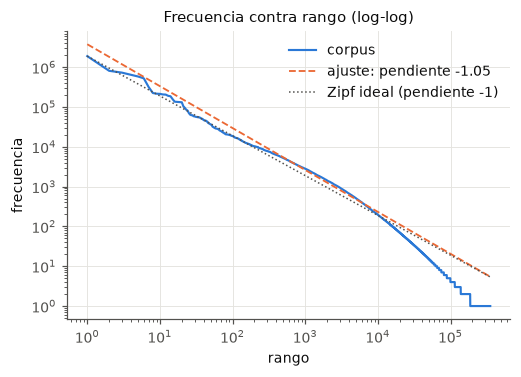

,subconjunto (25M),train completo (84.6M)
top 10,24.6 %,24.6 %
"top 1,000",64.0 %,64.0 %
"top 30,000",94.9 %,94.6 %


Pendiente ajustada (rangos 10–10,000): -1.053
Hapax legomena (frecuencia 1): 166040 = 47.1 % del vocabulario


In [5]:
print(f"Subconjunto: {stats['subset_articles']:,} artículos, {len(corpus.starts) - 1:,} párrafos, "
      f"{corpus.n_tokens:,} tokens, {len(corpus.words):,} tipos")
slope, intercept = T.zipf_fit(corpus.counts)
fig = P.zipf(corpus.counts, slope, intercept); plt.show()
cov = T.coverage(corpus.counts)
full_counts = np.array(sorted(stats["counter"].values(), reverse=True))
cov_full = T.coverage(full_counts)
display(pd.DataFrame({"subconjunto (25M)": {f"top {k:,}": f"{100 * v:.1f} %" for k, v in cov.items()},
                      "train completo (84.6M)": {f"top {k:,}": f"{100 * v:.1f} %" for k, v in cov_full.items()}}))
print(f"Pendiente ajustada (rangos 10–10,000): {slope:.3f}")
print("Hapax legomena (frecuencia 1):", int((corpus.counts == 1).sum()), f"= {100 * (corpus.counts == 1).mean():.1f} % del vocabulario")

**¿Se cumple la ley de Zipf?** Sí, de forma muy clara: en log-log la curva es casi una recta, con **pendiente ajustada de −1.05** en los rangos 10–10,000 (Zipf ideal: −1). Se desvía en los extremos, como es usual: las primeras palabras están algo por debajo de la recta y la cola de hapax forma escalones (frecuencias enteras pequeñas).

**Cobertura:** las **10** palabras más frecuentes (`the, of, and, in, to, a, was, on, as, 's`) cubren el **24.6 %** de todos los tokens; las **1,000** más frecuentes, el **64.0 %**; y las **30,000**, el **94.9 %** (94.6 % en el train completo). En el otro extremo, el **47 % del vocabulario son hapax** (aparecen una sola vez). Pocas palabras concentran casi todo el texto y la mayoría del vocabulario aparece tan poco que no se puede aprender un vector útil para ella. De ahí el `min_count` y el submuestreo.

### 2.5 Vocabulario y `min_count`

Con un umbral `min_count`, las palabras menos frecuentes se vuelven `<unk>`. Como los IDs están ordenados por frecuencia, el vocabulario con umbral $m$ son los IDs con frecuencia $\geq m$.

In [6]:
vt = pd.DataFrame(T.vocab_table(corpus.counts)).set_index("min_count")
display(vt.style.format({"vocab": "{:,}", "tokens_unk_%": "{:.2f} %"}))

,vocab,tokens_unk_%
min_count,,
1,"352,393",0.00 %
2,"186,353",0.66 %
5,"99,347",1.57 %
10,"65,443",2.46 %
20,"43,497",3.65 %
50,"24,785",5.98 %
100,"15,875",8.47 %


Con `min_count = 1` el vocabulario tiene 352,393 palabras; con **5** baja a **99,347** (−72 %) y solo el **1.57 %** de los tokens se vuelven desconocidos; con 20, 43,497 palabras y 3.65 % de `<unk>`; con 100, 15,875 palabras y 8.47 %. Usamos **`min_count = 5`** (el valor por defecto de word2vec): elimina la cola de palabras con muy poca evidencia, que además serían las más ruidosas, y conserva casi todo el texto. La iteración S13 prueba `min_count = 20`.

### 2.6 Submuestreo de palabras frecuentes

Word2Vec descarta cada aparición de una palabra $w$ con frecuencia relativa $f(w)$ con probabilidad $P_{desc}(w)$. El paper (Mikolov et al., 2013) usa $P_{desc} = 1 - \sqrt{t/f(w)}$; el código C de word2vec y gensim usan $P_{conservar} = (\sqrt{f/t} + 1)\, t/f$, algo menos agresiva. Usamos la segunda (la misma de gensim, para que ambas implementaciones vean el mismo corpus en promedio) con $t = 10^{-4}$, y se aplica sobre el vocabulario con `min_count = 5`.

In [7]:
base = corpus.restrict(5)
keep = T.keep_probability(base.counts, 1e-4)
f = base.counts / base.counts.sum()
paper = np.clip(1 - np.sqrt(1e-4 / f), 0, 1)
rng = np.random.default_rng(C.SEED)
mask = rng.random(base.n_tokens) < keep[base.ids]
rows = []
for w in ["the", "of", "and", "in", "was", "king", "computer", "france"]:
    i = base.words.index(w)
    occ = base.ids == i
    rows.append({"palabra": w, "frecuencia": int(base.counts[i]), "f (relativa)": f[i],
                 "% descartado (gensim/C)": 100 * (1 - keep[i]), "% descartado (paper)": 100 * paper[i],
                 "% descartado (muestra real)": 100 * (1 - mask[occ].mean())})
display(pd.DataFrame(rows).style.format({"frecuencia": "{:,}", "f (relativa)": "{:.5f}",
        "% descartado (gensim/C)": "{:.1f}", "% descartado (paper)": "{:.1f}", "% descartado (muestra real)": "{:.1f}"}))
print(f"Tokens: {base.n_tokens:,} -> {mask.sum():,} tras el submuestreo ({100 * (1 - mask.mean()):.1f} % descartado)")

,palabra,frecuencia,f (relativa),% descartado (gensim/C),% descartado (paper),% descartado (muestra real)
0,the,"1,892,657",0.07691,96.3,96.4,96.3
1,of,"809,638",0.03290,94.2,94.5,94.2
2,and,"728,565",0.02961,93.9,94.2,93.8
3,in,"640,280",0.02602,93.4,93.8,93.4
4,was,"316,584",0.01286,90.4,91.2,90.4
5,king,"9,979",0.00041,25.7,50.3,25.5
6,computer,"1,663",0.00007,0.0,0.0,0.0
7,france,"4,875",0.00020,0.0,29.0,0.0


Tokens: 24,608,578 -> 14,781,282 tras el submuestreo (39.9 % descartado)


**¿Qué porcentaje se descarta?** Con $t = 10^{-4}$ se descarta el **96.3 % de las apariciones de `the`**, el **94.2 % de `of`** y el **93.9 % de `and`** (la muestra real coincide con la probabilidad teórica). Palabras de contenido como `computer` o `france` (f < $t$) no se tocan, y `king` pierde un 26 %. En total se descarta el **39.9 % de los tokens** (24.6M → 14.8M por epoch).

**¿Por qué ayuda?**
1. **Información:** que `france` aparezca junto a `the` no dice casi nada (`the` co-ocurre con todo); que aparezca junto a `paris` sí. Al quitar la mayoría de las palabras funcionales, los pares de entrenamiento se concentran en co-ocurrencias informativas.
2. **Ventana efectiva más grande:** como se submuestrea antes de formar ventanas, los vecinos que quedan están más lejos en el texto original.
3. **Velocidad:** ~40 % menos tokens y pares por epoch, es decir, epochs ~40 % más rápidos.
4. **Equilibrio:** sin submuestreo, los vectores de las palabras más frecuentes recibirían millones de actualizaciones y dominarían el gradiente; Mikolov et al. reportan mejores vectores para palabras raras.

### 2.7 Pares (palabra central, contexto) para skip-gram

Cada token genera un par por cada vecino dentro de la ventana (sin cruzar párrafos). Con ventana fija $c$, un párrafo de longitud $L$ produce $\sum_{d=1}^{c} 2\max(L-d, 0)$ pares. Word2Vec usa una **ventana dinámica** (para cada centro se muestrea $b \sim U\{1..c\}$), que equivale a ponderar los contextos cercanos y deja en promedio una fracción $(c+1)/(2c)$ de los pares (60 % con $c=5$). Abajo se reportan ambos, antes y después del submuestreo, con $c = 5$. Al submuestrear antes de formar ventanas, la ventana efectiva se agranda: las palabras que quedan están, en promedio, más lejos en el texto original.

In [8]:
def starts_after(mask, starts):
    ck = np.concatenate([[0], np.cumsum(mask)])
    return ck[starts]

sub_starts = starts_after(mask, base.starts)
W = 5
pairs = pd.DataFrame({
    "tokens": [base.n_tokens, int(mask.sum())],
    "pares (ventana fija c=5)": [T.count_pairs(base.starts, W), T.count_pairs(sub_starts, W)],
    "pares esperados (ventana dinámica, b~U{1..5})": [T.expected_pairs_dynamic(base.starts, W),
                                                      T.expected_pairs_dynamic(sub_starts, W)],
}, index=["antes del submuestreo", "después del submuestreo"])
display(pairs.style.format("{:,}"))

# Los pares reales se generan en la GPU (src/sgns.make_pairs); un epoch de ejemplo:
ids_t = torch.tensor(base.ids, device=DEVICE); para_t = torch.tensor(base.para_ids, device=DEVICE)
kp_t = torch.tensor(keep, dtype=torch.float32, device=DEVICE)
torch.manual_seed(C.SEED)
cen, ctx, n_sub = S.make_pairs(ids_t, para_t, kp_t, W, DEVICE)
print(f"Epoch de ejemplo en la GPU: {len(cen):,} pares de {n_sub:,} tokens submuestreados")
print("Primeros pares:", [(base.words[a], base.words[b]) for a, b in zip(cen[:8].tolist(), ctx[:8].tolist())])
del ids_t, para_t, kp_t, cen, ctx; S.free_memory(DEVICE)

,tokens,pares (ventana fija c=5),"pares esperados (ventana dinámica, b~U{1..5})"
antes del submuestreo,"24,608,578","238,556,764","144,123,030"
después del submuestreo,"14,781,282","140,323,116","85,173,042"


Epoch de ejemplo en la GPU: 85,181,560 pares de 14,782,105 tokens submuestreados
Primeros pares: [('senjō', 'valkyria'), ('valkyria', '3'), ('3', 'unrecorded'), ('unrecorded', 'chronicles'), ('chronicles', 'japanese'), ('japanese', 'lit'), ('lit', 'valkyria'), ('valkyria', 'battlefield')]


**Pares por epoch.** Con ventana fija $c=5$ el corpus produce **238.6M pares** por epoch antes del submuestreo y **140.3M** después. Con la ventana dinámica de word2vec, que es la que usamos, se esperan **144.1M** antes y **85.2M** después; el epoch real generado en la GPU tiene **85.2M pares**. Es decir, el submuestreo reduce los pares un 41 % y la ventana dinámica otro 40 %.

## 3. Investigación: embeddings en PyTorch y gensim

### `nn.Embedding(num_embeddings, embedding_dim, padding_idx=None, sparse=False)`
Es una **tabla de búsqueda**: una matriz entrenable $W \in \mathbb{R}^{V \times d}$ y `forward(ids)` devuelve las filas `W[ids]`. Equivale a multiplicar un one-hot por $W$, pero sin construir el one-hot.
- `num_embeddings` ($V$): tamaño del vocabulario, número de filas.
- `embedding_dim` ($d$): dimensión de cada vector.
- `padding_idx`: la fila de ese índice se inicializa en ceros y **no recibe gradiente**; sirve para el relleno de secuencias.
- `sparse`: si es `True`, el gradiente de `weight` es un tensor disperso con solo las filas usadas en el batch; ahorra memoria y cómputo con vocabularios grandes, pero solo lo aceptan `optim.SGD`, `optim.SparseAdam` y `optim.Adagrad` (y no todos los backends; en MPS usamos gradientes densos).
- Otros: `max_norm` (renormaliza filas al consultarlas), `scale_grad_by_freq`.

### `nn.Embedding.from_pretrained(embeddings, freeze=True, padding_idx=None, ...)`
Crea la capa a partir de una matriz ya entrenada (por ejemplo GloVe). Con `freeze=True` (por defecto) la tabla queda con `requires_grad=False`: se usa como extractor fijo de características. Con `freeze=False` se hace **fine-tuning** junto con el resto del modelo.

### `nn.EmbeddingBag(num_embeddings, embedding_dim, mode="mean", padding_idx=None, ...)`
Calcula directamente una **agregación de bolsas de embeddings** sin materializar la matriz intermedia `[batch, longitud, d]`, ni rellenar documentos de distinta longitud. Recibe:
- `input`: todos los IDs del batch concatenados en un tensor 1D, y
- `offsets`: la posición donde empieza cada documento (bolsa) dentro de `input`.

`mode` define la agregación por bolsa: `"sum"` (suma), `"mean"` (promedio, el que usamos: no depende de la longitud del documento) y `"max"` (máximo por dimensión). También acepta `per_sample_weights` (con `"sum"`, p. ej. pesos TF-IDF) y `padding_idx` (esa fila se excluye de la agregación). Existe también `EmbeddingBag.from_pretrained`.

### gensim
- `Word2Vec(sentences, vector_size, window, min_count, sg, negative, sample, alpha, epochs, workers)`: entrena word2vec (`sg=1` skip-gram, `negative>0` negative sampling).
- `KeyedVectors`: contenedor de vectores con `most_similar`, `similarity`, `evaluate_word_analogies`, `evaluate_word_pairs`, `save`/`load` y `save_word2vec_format`.
- `gensim.downloader.load(...)`: descarga modelos preentrenados (GloVe ya convertido a `KeyedVectors`).

In [9]:
emb = nn.Embedding(num_embeddings=6, embedding_dim=3, padding_idx=0)
print("fila de padding:", emb.weight[0].tolist())
ids = torch.tensor([[1, 2, 0], [3, 0, 0]])                # 2 secuencias rellenadas con 0
out = emb(ids); out.sum().backward()
print("salida:", tuple(out.shape), "| gradiente de la fila 0:", emb.weight.grad[0].tolist())

pre = nn.Embedding.from_pretrained(torch.randn(6, 3), freeze=True)
print("from_pretrained(freeze=True) -> requires_grad =", pre.weight.requires_grad)

# EmbeddingBag: dos documentos de longitud 3 y 2, concatenados con offsets
W = torch.arange(18, dtype=torch.float32).reshape(6, 3)
inp, offsets = torch.tensor([1, 2, 4, 3, 5]), torch.tensor([0, 3])
for mode in ["sum", "mean", "max"]:
    bag = nn.EmbeddingBag.from_pretrained(W, mode=mode)
    print(f"{mode:>4}:", bag(inp, offsets).tolist())
print("manual mean doc0:", W[[1, 2, 4]].mean(0).tolist())

fila de padding: [0.0, 0.0, 0.0]
salida: (2, 3, 3) | gradiente de la fila 0: [0.0, 0.0, 0.0]
from_pretrained(freeze=True) -> requires_grad = False
 sum: [[21.0, 24.0, 27.0], [24.0, 26.0, 28.0]]
mean: [[7.0, 8.0, 9.0], [12.0, 13.0, 14.0]]
 max: [[12.0, 13.0, 14.0], [15.0, 16.0, 17.0]]
manual mean doc0: [7.0, 8.0, 9.0]


### Conceptos

**CBOW vs skip-gram.** Ambos son modelos de Word2Vec que aprenden vectores prediciendo co-ocurrencias en una ventana. **CBOW** promedia los vectores del contexto y predice la palabra central: es más rápido (un ejemplo por posición) y suaviza la información del contexto, por lo que funciona bien con palabras frecuentes. **Skip-gram** usa la palabra central para predecir cada palabra del contexto: genera un ejemplo por par (centro, contexto), es más lento, pero cada palabra recibe más actualizaciones propias y representa mejor palabras raras y relaciones semánticas finas. Con negative sampling, skip-gram (SGNS) maximiza $\log\sigma(u_o^\top v_c) + \sum_{k=1}^{K}\log\sigma(-u_k^\top v_c)$, con $K$ negativos muestreados de $P(w)\propto f(w)^{3/4}$.

**Dos matrices $W$ y $W'$.** Cada palabra tiene un vector como **centro** ($v_w$, en $W$) y otro como **contexto** ($u_w$, en $W'$). Usar una sola matriz obligaría a que $v_w^\top v_w$ fuera alto (una palabra rara vez aparece en su propio contexto, y el producto de un vector consigo mismo es su norma al cuadrado, que siempre es grande), y además separa los dos roles: dos palabras con contextos parecidos terminan con vectores $v$ parecidos. Al final normalmente **se conserva $W$** (la matriz de entrada); también se puede usar $W + W'$ (GloVe hace eso). Nosotros conservamos $W$, igual que gensim.

**Word2Vec (predictivo) vs GloVe (conteos).** Word2Vec es un modelo **predictivo y local**: recorre el corpus ventana por ventana y actualiza vectores con SGD para predecir el contexto. **GloVe** primero construye la matriz global de co-ocurrencias $X_{ij}$ y luego ajusta $w_i^\top \tilde w_j + b_i + \tilde b_j \approx \log X_{ij}$ con mínimos cuadrados ponderados $f(X_{ij})$, que limita el peso de los pares muy frecuentes. GloVe aprovecha estadísticas globales y entrena sobre la matriz (no sobre el corpus), mientras que Word2Vec escala con el tamaño del corpus. Levy & Goldberg (2014) mostraron que SGNS factoriza implícitamente una matriz PMI desplazada, así que ambos enfoques terminan muy relacionados.

## 4. Construcción y entrenamiento de los embeddings

### 4.1 Skip-gram con negative sampling en PyTorch

Implementación propia (`src/sgns.py`), sin usar la clase `Word2Vec` de gensim:

- **Modelo:** dos `nn.Embedding` ($W$ entrada y $W'$ salida), inicializadas como word2vec ($W \sim U(-\tfrac{0.5}{d}, \tfrac{0.5}{d})$, $W' = 0$). Pérdida: $-\log\sigma(u_o^\top v_c) - \sum_k \log\sigma(-u_k^\top v_c)$ promediada en el batch.
- **Datos por epoch (todo en la GPU):** submuestreo → ventana dinámica → pares sin cruzar párrafos → barajado → batches de 32,768 pares con $K$ negativos muestreados de una tabla unigrama$^{0.75}$ de 20M entradas.
- **Optimización:** Adam con decaimiento lineal del learning rate hasta ~0 (como word2vec). Se usa Adam y no SGD puro porque con batches grandes las filas de palabras muy frecuentes acumulan cientos de gradientes por paso; Adam normaliza la escala por parámetro, lo que permite batches de 32k (≈2M pares/s en la GPU) sin ajustar el lr a la frecuencia de cada palabra. El lr se eligió con un barrido (S1–S3).
- **Corpus:** subconjunto de 25.0M tokens (primeros 8,478 artículos de WikiText-103), el mismo para SGNS y gensim.
- **Registro por epoch:** pérdida (cada 500 pasos y promedio del epoch), analogías semánticas/sintácticas/total (3CosAdd, top-30k), Spearman en WordSim-353, 5 vecinos de `king, france, computer, good, january, run`, tiempo y memoria pico.

**Iteraciones.** S1 es la base (d=100, ventana 5, 5 negativos, $t=10^{-4}$, `min_count`=5, lr 0.01, 5 epochs); cada iteración cambia **un** hiperparámetro respecto a S1. La selección usa solo WordSim-353 y las analogías; SimLex-999 queda reservado para la sección 6.

In [10]:
display(pd.DataFrame({k: {**C.SGNS_BASE, **v} for k, v in C.SGNS_ITERATIONS.items()}).T)

,dim,window,negatives,sample,min_count,lr,epochs,batch_size,fraction,seed
S1,100.0,5.0,5.0,0.00010,5.0,0.010,5.0,32768.0,1.00,42.0
S2,100.0,5.0,5.0,0.00010,5.0,0.003,5.0,32768.0,1.00,42.0
S3,100.0,5.0,5.0,0.00010,5.0,0.030,5.0,32768.0,1.00,42.0
S4,50.0,5.0,5.0,0.00010,5.0,0.010,5.0,32768.0,1.00,42.0
S5,300.0,5.0,5.0,0.00010,5.0,0.010,5.0,32768.0,1.00,42.0
S6,100.0,5.0,5.0,0.00010,5.0,0.010,5.0,32768.0,0.25,42.0
S7,100.0,5.0,5.0,0.00010,5.0,0.010,5.0,32768.0,0.50,42.0
S8,100.0,2.0,5.0,0.00010,5.0,0.010,5.0,32768.0,1.00,42.0
S9,100.0,10.0,5.0,0.00010,5.0,0.010,5.0,32768.0,1.00,42.0
S10,100.0,5.0,15.0,0.00010,5.0,0.010,5.0,32768.0,1.00,42.0


In [11]:
runs, kvs = {}, {}
for name in C.SGNS_ITERATIONS:
    runs[name], kvs[name] = S.run_or_load(corpus, C.sgns_config(name), DEVICE)

[S1] cargada de results/runs (entrenada en 4.4 min)
[S2] cargada de results/runs (entrenada en 4.2 min)
[S3] cargada de results/runs (entrenada en 4.1 min)
[S4] cargada de results/runs (entrenada en 2.1 min)


[S5] cargada de results/runs (entrenada en 10.3 min)
[S6] cargada de results/runs (entrenada en 0.8 min)
[S7] cargada de results/runs (entrenada en 1.8 min)
[S8] cargada de results/runs (entrenada en 2.1 min)
[S9] cargada de results/runs (entrenada en 7.4 min)
[S10] cargada de results/runs (entrenada en 6.7 min)
[S11] cargada de results/runs (entrenada en 3.1 min)


[S12] cargada de results/runs (entrenada en 2.4 min)
[S13] cargada de results/runs (entrenada en 3.1 min)


In [12]:
CHANGE = {"S1": "base", "S2": "lr 0.003", "S3": "lr 0.03", "S4": "d=50", "S5": "d=300",
          "S6": "corpus 25 %", "S7": "corpus 50 %", "S8": "ventana 2", "S9": "ventana 10",
          "S10": "15 negativos", "S11": "2 negativos", "S12": "t=1e-5", "S13": "min_count 20"}

def iteration_row(name, r):
    c, h = r["cfg"], r["history"][-1]
    best_ep = max(r["history"], key=lambda x: x["an_total"])
    return {"iter": name, "cambio": CHANGE.get(name, ""), "dim": c["dim"], "ventana": c["window"],
            "neg": c["negatives"], "t": c["sample"], "min_count": c["min_count"], "lr": c["lr"],
            "epochs": c["epochs"], "tokens": r["corpus_tokens"], "vocab": r["vocab"],
            "pares/epoch (M)": np.mean([x["pairs"] for x in r["history"]]) / 1e6,
            "pérdida final": h["train_loss"], "an. sem": h["an_sem"], "an. sint": h["an_syn"],
            "an. total": h["an_total"], "WordSim ρ": h["wordsim"],
            "s/epoch": np.mean([x["time_s"] for x in r["history"]]), "total (min)": r["time_total_s"] / 60,
            "mem pico (MB)": r["peak_mem_mb"]}

iters = pd.DataFrame([iteration_row(n, r) for n, r in runs.items()]).set_index("iter")
iters.to_csv(C.RESULTS_DIR / "iteraciones_sgns.csv")
display(iters.style.format({"t": "{:.0e}", "lr": "{:g}", "tokens": "{:,}", "vocab": "{:,}",
        "pares/epoch (M)": "{:.1f}", "pérdida final": "{:.4f}", "an. sem": "{:.3f}", "an. sint": "{:.3f}",
        "an. total": "{:.3f}", "WordSim ρ": "{:.3f}", "s/epoch": "{:.0f}", "total (min)": "{:.1f}",
        "mem pico (MB)": "{:.0f}"}).background_gradient(subset=["an. total", "WordSim ρ"], cmap="Greens"))

,cambio,dim,ventana,neg,t,min_count,lr,epochs,tokens,vocab,pares/epoch (M),pérdida final,an. sem,an. sint,an. total,WordSim ρ,s/epoch,total (min),mem pico (MB)
iter,,,,,,,,,,,,,,,,,,,
S1,base,100,5,5,1e-04,5,0.01,5,"24,608,578","99,347",85.2,2.1258,0.427,0.462,0.452,0.677,53,4.4,1883
S2,lr 0.003,100,5,5,1e-04,5,0.003,5,"24,608,578","99,347",85.2,2.1442,0.373,0.462,0.436,0.665,51,4.2,1883
S3,lr 0.03,100,5,5,1e-04,5,0.03,5,"24,608,578","99,347",85.2,2.1737,0.420,0.420,0.420,0.656,50,4.1,1883
S4,d=50,50,5,5,1e-04,5,0.01,5,"24,608,578","99,347",85.2,2.1795,0.281,0.369,0.344,0.652,26,2.1,1731
S5,d=300,300,5,5,1e-04,5,0.01,5,"24,608,578","99,347",85.2,2.0411,0.526,0.432,0.459,0.678,124,10.3,2491
S6,corpus 25 %,100,5,5,1e-04,5,0.01,5,"6,072,816","45,333",20.7,2.1016,0.188,0.230,0.217,0.613,9,0.8,586
S7,corpus 50 %,100,5,5,1e-04,5,0.01,5,"12,238,542","67,486",42.1,2.1134,0.338,0.336,0.336,0.628,21,1.8,1037
S8,ventana 2,100,2,5,1e-04,5,0.01,5,"24,608,578","99,347",43.3,1.9789,0.322,0.447,0.410,0.658,25,2.1,1243
S9,ventana 10,100,10,5,1e-04,5,0.01,5,"24,608,578","99,347",151.8,2.2001,0.445,0.442,0.443,0.671,89,7.4,2939


**Historial por epoch de la base (S1)** y vecinos más cercanos de las palabras de control al final de cada epoch:

In [13]:
h = pd.DataFrame(runs["S1"]["history"]).set_index("epoch")
display(h[["train_loss", "pairs", "tokens_after_subsampling", "an_sem", "an_syn", "an_total", "wordsim", "time_s"]]
        .style.format({"train_loss": "{:.4f}", "pairs": "{:,}", "tokens_after_subsampling": "{:,}",
                       "an_sem": "{:.3f}", "an_syn": "{:.3f}", "an_total": "{:.3f}", "wordsim": "{:.3f}", "time_s": "{:.1f}"}))
nb = pd.DataFrame({ep["epoch"]: {w: ", ".join(v) for w, v in ep["neighbors"].items()} for ep in runs["S1"]["history"]})
nb.columns = [f"epoch {c}" for c in nb.columns]
display(nb)

,train_loss,pairs,tokens_after_subsampling,an_sem,an_syn,an_total,wordsim,time_s
epoch,,,,,,,,
1,2.3319,"85,181,560","14,782,105",0.252,0.268,0.263,0.649,52.4
2,2.2162,"85,174,235","14,782,716",0.327,0.358,0.349,0.653,51.5
3,2.1793,"85,160,865","14,780,602",0.396,0.407,0.404,0.654,52.1
4,2.1503,"85,171,869","14,779,309",0.436,0.439,0.438,0.670,55.6
5,2.1258,"85,183,909","14,782,996",0.427,0.462,0.452,0.677,53.3


,epoch 1,epoch 2,epoch 3,epoch 4,epoch 5
king,"vira, edward, eógan, vi, constantius","throne, ballala, prince, monarch, eógan","throne, edward, prince, monarch, queen","vi, throne, prince, queen, edward","throne, vi, edward, prince, queen"
france,"spain, italy, austria, belgium, germany","spain, italy, belgium, netherlands, portugal","italy, spain, belgium, austria, germany","spain, italy, belgium, netherlands, germany","spain, italy, belgium, netherlands, austria"
computer,"software, computers, graphics, real-time, labs","computers, software, real-time, interface, hardware","computers, software, interface, real-time, desktop","computers, software, desktop, computing, real-time","computers, software, desktop, computing, real-time"
good,"things, really, luck, bad, fun","bad, excellent, really, nice, perfect","bad, excellent, luck, really, pretty","bad, excellent, pretty, luck, really","bad, excellent, pretty, luck, really"
january,"october, february, april, march, november","march, february, november, december, october","february, december, march, july, april","february, december, march, june, april","february, december, march, november, june"
run,"2-run, ran, running, runs, 6-yard","2-run, running, ran, walk-off, 1-yard","running, 2-run, runs, walk-off, ran","running, ran, runs, 2-run, drive","running, ran, runs, 2-run, walk-off"


**Evolución de S1.** En el primer epoch los vecinos ya son temáticamente correctos (`january` → otros meses, `france` → países europeos), pero `king` todavía mezcla nombres propios raros (`vira, eógan, constantius`). Al epoch 5 converge a `throne, prince, queen`. La accuracy de analogías sube de **0.263 a 0.452** y WordSim de **0.649 a 0.677**, y siguen subiendo al final, por lo que más epochs deberían ayudar (ver 4.2). Los vecinos reflejan el dominio de Wikipedia: `run` está cerca de `2-run` y `walk-off` (béisbol), y `good` tiene como vecino más cercano a su antónimo `bad`. Es el comportamiento típico de los embeddings distribucionales: los antónimos aparecen en los mismos contextos.

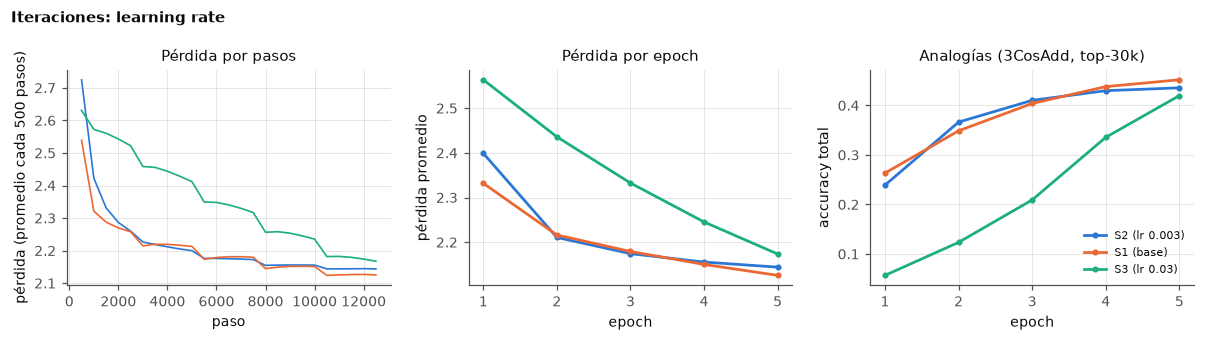

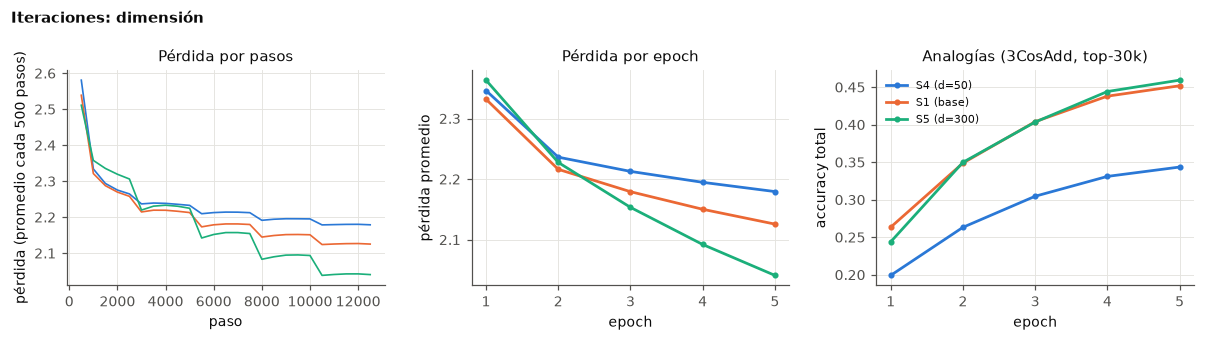

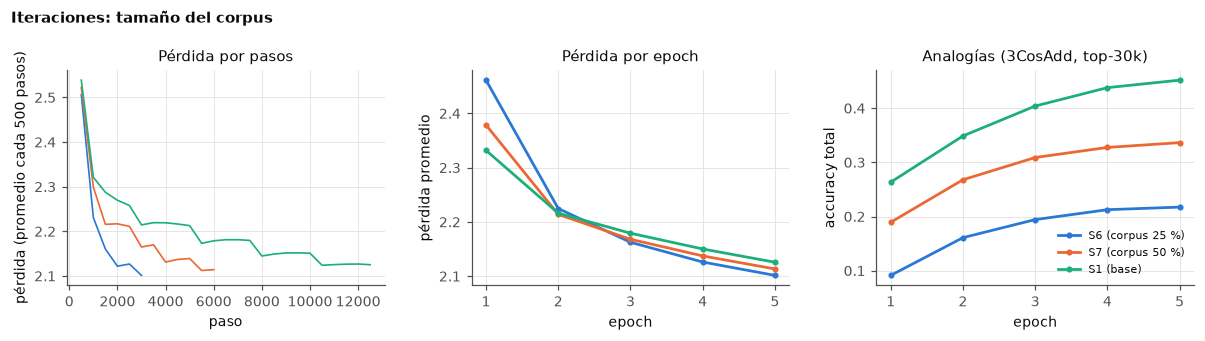

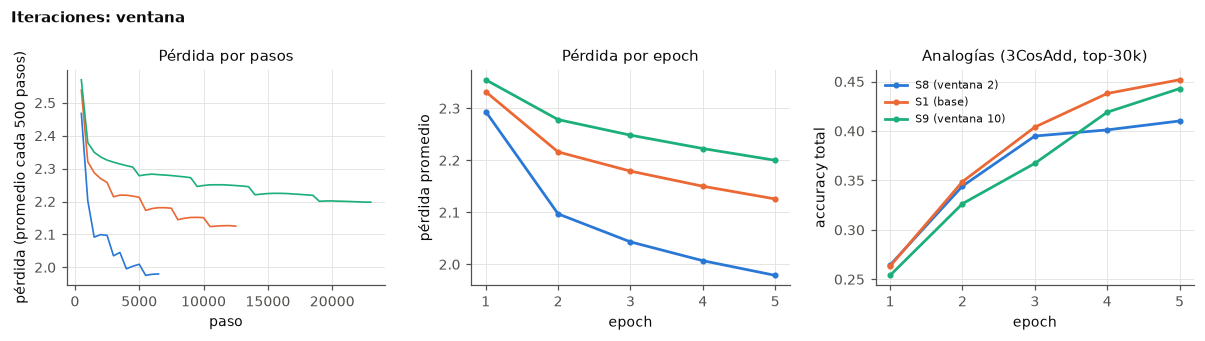

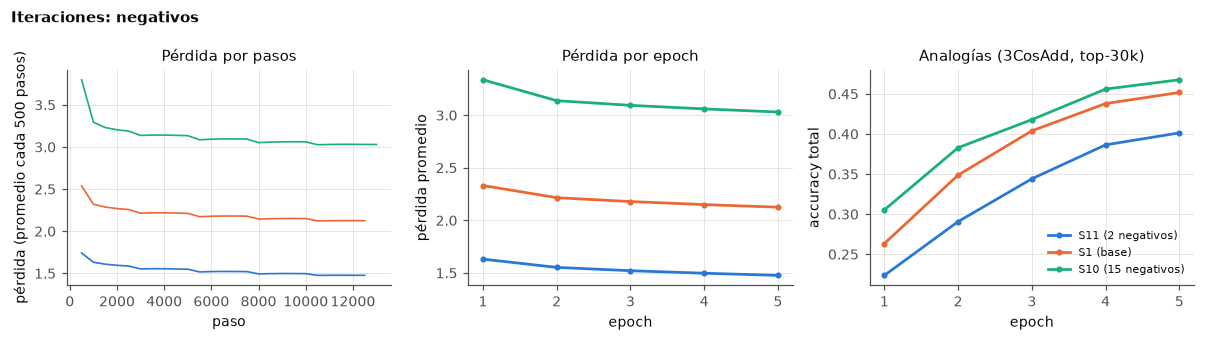

In [14]:
groups = {
    "learning rate": ["S2", "S1", "S3"], "dimensión": ["S4", "S1", "S5"],
    "tamaño del corpus": ["S6", "S7", "S1"], "ventana": ["S8", "S1", "S9"], "negativos": ["S11", "S1", "S10"],
}
for g, names in groups.items():
    rs = [{**runs[n], "label": f"{n} ({CHANGE[n]})"} for n in names]
    P.training_curves(rs, f"curvas_{g.split()[0]}", f"Iteraciones: {g}"); plt.show()

**Efecto de cada hiperparámetro** (accuracy total de analogías al epoch 5; semánticas / sintácticas):
- **Learning rate:** 0.003 aprende más lento (0.436); 0.03 es inestable al inicio (0.057 en el epoch 1) y no alcanza a recuperarse del todo (0.420); **0.01** es el mejor (0.452).
- **Dimensión:** d=50 se queda corta (0.344); **d=300 da el máximo (0.459)**, sobre todo en analogías semánticas (0.526 contra 0.427), pero cuesta 2.3× más tiempo y la ganancia frente a d=100 es pequeña. WordSim prácticamente no cambia (0.65–0.68).
- **Tamaño del corpus:** 25 % → 0.217, 50 % → 0.336, 100 % → 0.452. Es el efecto más grande: **+0.116 cada vez que se duplica el corpus**, sin señales de saturación en este rango.
- **Ventana:** ventana 2 favorece lo **sintáctico** (0.447 sint. contra 0.322 sem.); ventana 10 favorece lo **semántico** (0.445 sem., la más alta con d=100 y 5 negativos). Ver la discusión.
- **Negativos:** 2 → 0.401, 5 → 0.452, **15 → 0.468** (sem. 0.492), a cambio de más tiempo (3.1 → 4.4 → 6.7 min).
- **Submuestreo** más agresivo ($t=10^{-5}$) → 0.382: descarta demasiado (49M pares por epoch) y castiga sobre todo lo sintáctico (0.367), que depende de palabras frecuentes.
- **min_count 20** → 0.431 y la mejor WordSim (0.684), pero con vocabulario de 43k (más OOV en AG News).

**¿Una pérdida más baja implica siempre mejores embeddings? No.**
1. La pérdida **no es comparable entre configuraciones con objetivos distintos**: con 2 negativos la pérdida final es la más baja de todas (1.48) y con 15 la más alta (3.03), simplemente porque suma más términos, y sin embargo 15 negativos da mejores analogías. Con ventana 2 la pérdida es menor que con 5 (1.98 contra 2.13) porque predecir vecinos inmediatos es más fácil, pero los embeddings son peores.
2. Incluso dentro de una misma corrida, la pérdida baja de forma monótona pero las métricas no siempre suben: en la configuración final, WordSim baja de 0.645 (epoch 2) a 0.623 (epoch 4) mientras la pérdida sigue bajando.

La pérdida mide qué tan bien se predicen co-ocurrencias, no qué tan bien se ordena geométricamente el espacio para analogías o similitud. Por eso la selección se hace con benchmarks externos.

In [15]:
# Historial completo por epoch de todas las iteraciones (analogías y WordSim)
hist_all = pd.concat({n: pd.DataFrame(r["history"]).set_index("epoch")[["train_loss", "an_sem", "an_syn", "an_total", "wordsim", "time_s"]]
                      for n, r in runs.items()}, names=["iter"])
hist_all.to_csv(C.RESULTS_DIR / "historial_sgns.csv")
display(hist_all.unstack(0)["an_total"].style.format("{:.3f}").set_caption("Accuracy total de analogías por epoch"))

iter,S1,S2,S3,S4,S5,S6,S7,S8,S9,S10,S11,S12,S13
epoch,,,,,,,,,,,,,
1,0.263,0.239,0.057,0.199,0.244,0.091,0.189,0.264,0.254,0.305,0.224,0.210,0.275
2,0.349,0.366,0.124,0.263,0.350,0.161,0.268,0.344,0.327,0.383,0.291,0.289,0.344
3,0.404,0.410,0.209,0.305,0.403,0.194,0.309,0.395,0.367,0.418,0.344,0.327,0.380
4,0.438,0.430,0.336,0.331,0.444,0.213,0.328,0.401,0.419,0.456,0.387,0.369,0.423
5,0.452,0.436,0.420,0.344,0.459,0.217,0.336,0.410,0.443,0.468,0.401,0.382,0.431


### 4.2 Mejor configuración

Se elige con la suma de accuracy total de analogías y Spearman de WordSim-353 (ambos en [0, 1]). Con lo aprendido en las iteraciones se entrena una configuración final que combina los mejores valores de cada hiperparámetro, con **d = 100** para compararla directamente con GloVe.

In [16]:
score = iters["an. total"] + iters["WordSim ρ"]
display(score.sort_values(ascending=False).head(6).rename("an. total + WordSim ρ").to_frame().style.format("{:.3f}"))
best_cfg = C.sgns_config("SBEST", **C.SGNS_BEST)
print("Configuración final:", best_cfg)
runs["SBEST"], kvs["SBEST"] = S.run_or_load(corpus, best_cfg, DEVICE)
CHANGE["SBEST"] = "mejor combinación"
iters.loc["SBEST"] = iteration_row("SBEST", runs["SBEST"])
iters.to_csv(C.RESULTS_DIR / "iteraciones_sgns.csv")
display(iters.loc[["S1", "SBEST"]].T)

,an. total + WordSim ρ
iter,
S5,1.137
S1,1.129
S10,1.126
S13,1.115
S9,1.114
S2,1.101


Configuración final: {'name': 'SBEST', 'dim': 100, 'window': 5, 'negatives': 15, 'sample': 0.0001, 'min_count': 5, 'lr': 0.01, 'epochs': 10, 'batch_size': 32768, 'fraction': 1.0, 'seed': 42}


[SBEST] epoch 1/10  loss 3.3416  analogias sem 0.313 sin 0.279 total 0.289  wordsim 0.614  (82s, 85.2M pares)


[SBEST] epoch 2/10  loss 3.1565  analogias sem 0.385 sin 0.341 total 0.354  wordsim 0.645  (81s, 85.2M pares)


[SBEST] epoch 3/10  loss 3.1258  analogias sem 0.379 sin 0.369 total 0.372  wordsim 0.634  (80s, 85.2M pares)


...

[SBEST] epoch 7/10  loss 3.0535  analogias sem 0.475 sin 0.449 total 0.456  wordsim 0.649  (81s, 85.2M pares)


[SBEST] epoch 8/10  loss 3.0376  analogias sem 0.485 sin 0.465 total 0.471  wordsim 0.653  (77s, 85.2M pares)


[SBEST] epoch 9/10  loss 3.0225  analogias sem 0.498 sin 0.473 total 0.481  wordsim 0.658  (77s, 85.2M pares)


[SBEST] epoch 10/10  loss 3.0086  analogias sem 0.503 sin 0.477 total 0.484  wordsim 0.664  (77s, 85.2M pares)


iter,S1,SBEST
cambio,base,mejor combinación
dim,100,100
ventana,5,5
neg,5,15
t,0.0001,0.0001
min_count,5,5
lr,0.01,0.01
epochs,5,10
tokens,24608578,24608578
vocab,99347,99347


**Configuración final (SBEST).** Por la suma analogías + WordSim, las mejores iteraciones son S5 (d=300), S1 (base) y S10 (15 negativos), muy cerca entre sí. Para la configuración final se combinan los efectos positivos que no cambian la dimensión: **15 negativos** (el mayor aumento en analogías con d=100) y **10 epochs** (todas las curvas seguían subiendo en el epoch 5). Se mantienen d=100 (para comparar con GloVe), ventana 5 (el mejor equilibrio sem./sint.), $t=10^{-4}$ y `min_count=5`. Resultado: **0.484 en analogías** (sem. 0.503, sint. 0.477) y **0.664 en WordSim** (algo menos que S1, que con 0.677 mide mejor la similitud y peor las analogías), en **13.3 min** de GPU y con **1.9 GB** de memoria pico.

### 4.3 Word2Vec de gensim (referencia)

Mismo corpus (los mismos párrafos de tokens), mismo `min_count` (por lo tanto el mismo vocabulario), skip-gram con negative sampling (`sg=1, hs=0`) y los mismos `vector_size`, `window`, `negative`, `sample` y `epochs` que la configuración final. El único hiperparámetro que no se puede igualar es el learning rate: gensim usa SGD por par con `alpha=0.025` decayendo linealmente (su valor por defecto), mientras que el nuestro usa Adam por batch.

In [17]:
from gensim.models import KeyedVectors
g_cfg = {**best_cfg, "name": "GENSIM", "alpha": 0.025}
g_path = C.VECTORS_DIR / "GENSIM.kv"
if g_path.exists():
    gensim_run = json.load(open(C.RUNS_DIR / "GENSIM.json")); kv_gensim = KeyedVectors.load(str(g_path))
    print(f"[GENSIM] cargado de results/runs (entrenado en {gensim_run['time_total_s'] / 60:.1f} min)")
else:
    gensim_run, kv_gensim = S.train_gensim(corpus, g_cfg, workers=12)
    json.dump(gensim_run, open(C.RUNS_DIR / "GENSIM.json", "w"), indent=1, default=float)
    kv_gensim.save(str(g_path))
print("Vocabulario idéntico al del SGNS:", set(kv_gensim.index_to_key) == set(kvs["SBEST"].index_to_key),
      f"({len(kv_gensim):,} palabras)")
gh = pd.DataFrame(gensim_run["history"]).set_index("epoch")
display(gh[["train_loss_sum", "an_sem", "an_syn", "an_total", "wordsim", "time_s"]].style.format(
    {"train_loss_sum": "{:,.0f}", "an_sem": "{:.3f}", "an_syn": "{:.3f}", "an_total": "{:.3f}", "wordsim": "{:.3f}", "time_s": "{:.1f}"}))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


[GENSIM] epoch 10  analogias total 0.478  wordsim 0.672  (16s)
Vocabulario idéntico al del SGNS: True (99,347 palabras)


,train_loss_sum,an_sem,an_syn,an_total,wordsim,time_s
epoch,,,,,,
1,"17,132,092",0.095,0.169,0.147,0.531,15.4
2,"14,616,494",0.159,0.276,0.241,0.599,15.5
3,"14,545,898",0.214,0.333,0.298,0.623,15.7
4,"14,612,032",0.264,0.371,0.340,0.625,15.8
5,"7,709,356",0.305,0.409,0.378,0.638,15.9
6,"2,499,632",0.331,0.431,0.402,0.653,16.4
7,"2,417,192",0.372,0.459,0.433,0.663,15.9
8,"2,251,936",0.396,0.473,0.450,0.675,16.0
9,"2,117,808",0.422,0.491,0.471,0.672,16.0


### 4.4 GloVe preentrenado

`glove-wiki-gigaword-100` se usa tal cual. Para que el evaluador de analogías (top-30k) se comporte igual en los tres modelos, sus palabras ya vienen ordenadas por frecuencia.

In [18]:
import gensim.downloader as api
kv_glove = api.load("glove-wiki-gigaword-100")
print(f"GloVe: {len(kv_glove):,} palabras, d = {kv_glove.vector_size}")
MODELS = {"SGNS (propio)": kvs["SBEST"], "Word2Vec gensim": kv_gensim, "GloVe 6B": kv_glove}
quick = {m: E.quick_eval(kv, DEVICE) for m, kv in MODELS.items()}
display(pd.DataFrame({m: {k: v for k, v in q.items() if k != "neighbors"} for m, q in quick.items()}).T.style.format("{:.3f}"))
display(pd.DataFrame({m: {w: ", ".join(n) for w, n in q["neighbors"].items()} for m, q in quick.items()}))

GloVe: 400,000 palabras, d = 100


,an_sem,an_syn,an_total,wordsim
SGNS (propio),0.503,0.477,0.484,0.664
Word2Vec gensim,0.438,0.495,0.478,0.672
GloVe 6B,0.655,0.655,0.655,0.533


,SGNS (propio),Word2Vec gensim,GloVe 6B
king,"throne, vi, nephew, reign, monarch","harefoot, uncrowned, rakoto, curthose, bagler","prince, queen, son, brother, monarch"
france,"spain, italy, belgium, portugal, germany","spain, italy, belgium, austria, portugal","belgium, french, britain, spain, paris"
computer,"computers, software, computing, real-time, hardware","computers, desktop, mpi, minicomputer, pdp-1","computers, software, technology, pc, hardware"
good,"bad, excellent, luck, decent, nice","bad, excellent, decent, freakin, glutton","better, sure, really, kind, very"
january,"february, december, march, november, april","december, february, march, november, april","december, october, february, november, september"
run,"running, runs, ran, drive, home","running, inside-the-park, 2-run, 76-yard, 72-yard","running, runs, ran, out, go"


**Los tres modelos** (vocabulario top-30k de cada uno). Nuestro SGNS y gensim quedan casi empatados en analogías (**0.484** contra **0.478**) y en WordSim (0.664 contra 0.672), muy por debajo de GloVe en analogías (**0.655**), pero **por encima de GloVe en WordSim-353** (0.533). WordSim mezcla similitud y asociación temática, y un corpus solo de Wikipedia, con ventanas pequeñas, captura bien la asociación. Los vecinos de gensim incluyen más palabras raras (`harefoot`, `uncrowned`, `rakoto` para *king*): el SGD por par de gensim da a cada aparición de una palabra rara una actualización completa, mientras que Adam en batches de 32k suaviza esas actualizaciones. Los vecinos de GloVe son más generales (`technology`, `pc` para *computer*) porque su corpus incluye noticias.

*Nota:* gensim 4.4 con numpy 2.x imprime ocasionalmente `Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'` desde su código Cython (unas pocas veces por epoch, sobre ~85M pares). La advertencia no interrumpe el entrenamiento y las métricas de gensim son las esperadas (vocabulario idéntico y accuracy casi igual a la de nuestra implementación).

**Validación del evaluador.** Nuestro evaluador de analogías (`src/evaluation.py`, vectorizado en la GPU) debe dar lo mismo que `gensim.KeyedVectors.evaluate_word_analogies` con `restrict_vocab=30000`:

In [19]:
for m, kv in MODELS.items():
    t0 = time.perf_counter(); ours = E.evaluate_analogies(kv, methods=("add",), device=DEVICE)["add"]["total"]; t1 = time.perf_counter()
    ref, _ = kv.evaluate_word_analogies(E.ANALOGIES, restrict_vocab=30000); t2 = time.perf_counter()
    print(f"{m:16s} propio {ours:.4f} ({t1 - t0:.1f}s) | gensim {ref:.4f} ({t2 - t1:.1f}s)")

SGNS (propio)    propio 0.4844 (0.1s) | gensim 0.4844 (2.9s)


Word2Vec gensim  propio 0.4780 (0.2s) | gensim 0.4780 (2.9s)


GloVe 6B         propio 0.6549 (0.2s) | gensim 0.6549 (4.3s)


## 5. Verificación de la aritmética vectorial

### 5.1 Analogías individuales

`E.analogia(kv, a, b, c, k)` resuelve «a es a b como c es a ?» con 3CosAdd: normaliza los vectores, calcula $t = \hat b - \hat a + \hat c$, lo normaliza, ordena todo el vocabulario por coseno con $t$ y excluye $a$, $b$ y $c$. Primero se verifica que coincide con `most_similar(positive=[b, c], negative=[a])` de gensim.

In [20]:
import inspect
print(inspect.getsource(E.analogia))
checks = [("man", "king", "woman"), ("france", "paris", "italy"), ("good", "better", "bad"), ("walk", "walked", "swim")]
for m, kv in MODELS.items():
    same = all([w for w, _ in E.analogia(kv, a, b, c, 5)] == [w for w, _ in kv.most_similar(positive=[b, c], negative=[a], topn=5)]
               for a, b, c in checks)
    sims_ok = all(np.allclose([s for _, s in E.analogia(kv, a, b, c, 5)], [s for _, s in kv.most_similar(positive=[b, c], negative=[a], topn=5)], atol=1e-5)
                  for a, b, c in checks)
    print(f"{m:16s} mismas palabras: {same} | mismas similitudes: {sims_ok}")

def analogia(kv, a, b, c, k=5, exclude=True):
    """Resuelve «a es a b como c es a ?» con 3CosAdd sobre vectores normalizados.

    target = b_hat - a_hat + c_hat; devuelve las k palabras con mayor coseno contra target
    (excluyendo a, b y c si exclude=True) junto con su similitud.
    """
    U = _unit(kv)
    i = kv.key_to_index
    target = U[i[b]] - U[i[a]] + U[i[c]]
    target /= np.linalg.norm(target)
    sims = U @ target
    if exclude:
        sims[[i[a], i[b], i[c]]] = -np.inf
    top = np.argpartition(-sims, k)[:k]
    top = top[np.argsort(-sims[top])]
    return [(kv.index_to_key[j], float(sims[j])) for j in top]

SGNS (propio)    mismas palabras: True | mismas similitudes: True
Word2Vec gensim  mismas palabras: True | mismas similitudes: True
GloVe 6B         mismas palabras: True | mismas similitudes: True


In [21]:
MIS_ANALOGIAS = [  # (tipo, a, b, c, d): «a es a b como c es a d»
    ("género", "man", "king", "woman", "queen"), ("género", "brother", "sister", "father", "mother"),
    ("género", "actor", "actress", "prince", "princess"),
    ("país–capital", "france", "paris", "japan", "tokyo"), ("país–capital", "germany", "berlin", "italy", "rome"),
    ("país–capital", "spain", "madrid", "russia", "moscow"),
    ("país–gentilicio", "france", "french", "germany", "german"), ("país–gentilicio", "china", "chinese", "mexico", "mexican"),
    ("país–gentilicio", "england", "english", "brazil", "brazilian"),
    ("comparativo/superlativo", "good", "better", "bad", "worse"), ("comparativo/superlativo", "big", "biggest", "small", "smallest"),
    ("comparativo/superlativo", "fast", "faster", "strong", "stronger"),
    ("tiempo verbal", "walk", "walked", "swim", "swam"), ("tiempo verbal", "go", "went", "take", "took"),
    ("tiempo verbal", "playing", "played", "writing", "wrote"),
    ("plural", "car", "cars", "child", "children"), ("plural", "mouse", "mice", "man", "men"),
    ("plural", "city", "cities", "country", "countries"),
    ("empresa–producto", "microsoft", "windows", "apple", "iphone"), ("moneda", "japan", "yen", "europe", "euro"),
]
rows, rows_noex = [], []
for tipo, a, b, c, d in MIS_ANALOGIAS:
    for m, kv in MODELS.items():
        if not all(w in kv.key_to_index for w in (a, b, c, d)):
            rows.append({"tipo": tipo, "analogía": f"{a}:{b} :: {c}:?", "esperada": d, "modelo": m, "top-5": "(OOV)"}); continue
        top = E.analogia(kv, a, b, c, 5)
        rank, cos = E.answer_rank(kv, a, b, c, d)
        rows.append({"tipo": tipo, "analogía": f"{a}:{b} :: {c}:?", "esperada": d, "modelo": m,
                     "top-5": ", ".join(f"{w} ({s:.2f})" for w, s in top), "rango": rank, "cos(d, t)": cos})
        top_ne = E.analogia(kv, a, b, c, 3, exclude=False)
        rank_ne, _ = E.answer_rank(kv, a, b, c, d, exclude=False)
        rows_noex.append({"analogía": f"{a}:{b} :: {c}:{d}", "modelo": m,
                          "top-3 sin excluir": ", ".join(f"{w} ({s:.2f})" for w, s in top_ne),
                          "1.º es": "c" if top_ne[0][0] == c else ("b" if top_ne[0][0] == b else ("d" if top_ne[0][0] == d else "otra")),
                          "rango de d": rank_ne})
ind = pd.DataFrame(rows)
ind.to_csv(C.RESULTS_DIR / "analogias_individuales.csv", index=False)
with pd.option_context("display.max_colwidth", 110, "display.max_rows", 100):
    display(ind.style.format({"cos(d, t)": "{:.3f}", "rango": "{:.0f}"}).hide(axis="index"))
summary = ind.groupby("modelo").agg(acierto_top1=("rango", lambda r: (r == 1).mean()), en_top5=("rango", lambda r: (r <= 5).mean()),
                                    rango_mediano=("rango", "median"), cos_medio=("cos(d, t)", "mean"))
display(summary.style.format("{:.2f}"))

tipo,analogía,esperada,modelo,top-5,rango,"cos(d, t)"
género,man:king :: woman:?,queen,SGNS (propio),"queen (0.68), consort (0.64), monarch (0.60), coronation (0.60), throne (0.60)",1,0.680
género,man:king :: woman:?,queen,Word2Vec gensim,"consort (0.73), jagiellon (0.72), queen (0.70), eanflæd (0.68), regnant (0.68)",3,0.702
género,man:king :: woman:?,queen,GloVe 6B,"queen (0.77), monarch (0.68), throne (0.68), daughter (0.66), princess (0.65)",1,0.770
género,brother:sister :: father:?,mother,SGNS (propio),"mother (0.73), daughter (0.69), sisters (0.68), her (0.66), husband (0.65)",1,0.733
género,brother:sister :: father:?,mother,Word2Vec gensim,"mother (0.74), 7-year-old (0.74), sisters (0.71), daughter (0.69), homemaker (0.69)",1,0.741
género,brother:sister :: father:?,mother,GloVe 6B,"mother (0.90), daughter (0.83), wife (0.80), grandmother (0.79), her (0.76)",1,0.898
género,actor:actress :: prince:?,princess,SGNS (propio),"princess (0.74), queen (0.66), duchess (0.66), empress (0.63), beatrice (0.63)",1,0.740
género,actor:actress :: prince:?,princess,Word2Vec gensim,"princess (0.76), queen (0.71), duchess (0.69), saxe-coburg-saalfeld (0.67), hrh (0.67)",1,0.761
género,actor:actress :: prince:?,princess,GloVe 6B,"princess (0.82), queen (0.72), duchess (0.68), daughter (0.67), niece (0.63)",1,0.824
país–capital,france:paris :: japan:?,tokyo,SGNS (propio),"tokyo (0.79), osaka (0.62), nagoya (0.62), nippon (0.61), sapporo (0.58)",1,0.792


,acierto_top1,en_top5,rango_mediano,cos_medio
modelo,,,,
GloVe 6B,0.80,0.90,1.00,0.80
SGNS (propio),0.75,0.75,1.00,0.65
Word2Vec gensim,0.60,0.80,1.00,0.67


**Analogías individuales.** Con exclusión, GloVe acierta en primer lugar **16/20**, nuestro SGNS **15/20** y gensim **12/20**. Las relaciones país–gentilicio, la mayoría de país–capital, comparativos regulares, tiempos verbales y plurales regulares funcionan en los tres modelos, con cosenos de 0.6–0.9 entre la respuesta y el vector resultante.

Los fallos son ilustrativos:
- `germany:berlin :: italy:?` → `venice`/`milan` (rome en el puesto 8): en Wikipedia, Venecia y Milán aparecen en los mismos contextos culturales que Berlín.
- `big:biggest :: small:?` → `large`/`largest` (puesto 11 en SGNS y GloVe): la dirección «tamaño» domina sobre la de «superlativo».
- `mouse:mice :: man:?` → plural irregular y poco frecuente (`mice`), puesto 24.
- `microsoft:windows :: apple:?` (puesto 1,132) y `japan:yen :: europe:?` (12,558): en WikiText, *windows* son ventanas de edificios y *apple* es la fruta. Además, *europe* no es un país, así que la relación no es la misma. GloVe, con noticias, deja `ipod` en el top-5 y `euro` en el puesto 2.

Los modelos entrenados en un corpus pequeño y de un solo dominio fallan justo donde el sentido dominante de una palabra cambia de dominio.

In [22]:
noex = pd.DataFrame(rows_noex)
with pd.option_context("display.max_colwidth", 90, "display.max_rows", 100):
    display(noex)
display(noex.groupby("modelo")["1.º es"].value_counts().unstack(fill_value=0))

,analogía,modelo,top-3 sin excluir,1.º es,rango de d
0,man:king :: woman:queen,SGNS (propio),"king (0.79), queen (0.68), consort (0.64)",b,2
1,man:king :: woman:queen,Word2Vec gensim,"king (0.79), consort (0.73), jagiellon (0.72)",b,4
2,man:king :: woman:queen,GloVe 6B,"king (0.84), queen (0.77), monarch (0.68)",b,2
3,brother:sister :: father:mother,SGNS (propio),"sister (0.83), mother (0.73), father (0.71)",b,2
4,brother:sister :: father:mother,Word2Vec gensim,"sister (0.86), mother (0.74), 7-year-old (0.74)",b,2
5,brother:sister :: father:mother,GloVe 6B,"sister (0.93), mother (0.90), daughter (0.83)",b,2
6,actor:actress :: prince:princess,SGNS (propio),"prince (0.88), princess (0.74), queen (0.66)",c,2
7,actor:actress :: prince:princess,Word2Vec gensim,"prince (0.87), princess (0.76), queen (0.71)",c,2
8,actor:actress :: prince:princess,GloVe 6B,"prince (0.87), princess (0.82), queen (0.72)",c,2
9,france:paris :: japan:tokyo,SGNS (propio),"tokyo (0.79), japan (0.75), osaka (0.62)",d,1


1.º es,b,c,d,otra
modelo,,,,
GloVe 6B,4,6,8,2
SGNS (propio),5,9,6,0
Word2Vec gensim,5,10,4,1


**Sin excluir las palabras de la consulta**, el primer lugar casi nunca es la respuesta: en nuestro SGNS el top-1 es **c** en 9/20 analogías (p. ej. `child` para `car:cars :: child:?`) y **b** en 5/20 (`king` para `man:king :: woman:?`); la respuesta correcta queda primera solo en 6/20. En GloVe pasa lo mismo (c 6, b 4, d 8). El vector $\hat b - \hat a + \hat c$ sigue estando más cerca de $b$ o de $c$ que de $d$: el desplazamiento $\hat b - \hat a$ es pequeño comparado con la norma de los vectores, así que la «aritmética» solo mueve el punto un poco en la dirección correcta. La exclusión de a, b y c no es un detalle de implementación: sin ella, la mayoría de las analogías «fallaría». Esto muestra que la igualdad king − man + woman = queen es solo aproximada.

### 5.2 Evaluación sistemática

**Vocabulario compartido:** las 30,000 palabras más frecuentes (según nuestro corpus) que existen en los tres modelos. Como SGNS y gensim tienen el mismo vocabulario, en la práctica es la intersección del vocabulario de nuestro corpus con el de GloVe. Las respuestas se buscan solo dentro de ese vocabulario y una pregunta se evalúa solo si sus 4 palabras están en él, así que **las preguntas evaluadas son las mismas para los tres modelos**.

In [23]:
shared = [w for w in kvs["SBEST"].index_to_key if w in kv_gensim.key_to_index and w in kv_glove.key_to_index][:30_000]
print(f"Vocabulario compartido: {len(shared):,} palabras (de la #1 '{shared[0]}' a la #{len(shared):,} '{shared[-1]}')")
full = {m: E.evaluate_analogies(kv, vocab=shared, device=DEVICE) for m, kv in MODELS.items()}
print(f"Cobertura: {full['GloVe 6B']['n_eval']:,} / {full['GloVe 6B']['n_total']:,} preguntas = {100 * full['GloVe 6B']['coverage']:.1f} %")
rows = []
for sec in E.SECTIONS:
    r = {"categoría": sec, "tipo": "semántica" if sec in E.SEMANTIC else "sintáctica",
         "preguntas": full["GloVe 6B"]["add"]["by_category"][sec][1],
         "total en archivo": sum(1 for q in E.QUESTIONS if q[0] == sec)}
    for m in MODELS:
        for meth, lbl in [("add", "Add"), ("mul", "Mul")]:
            r[f"{m} {lbl}"] = full[m][meth]["by_category"][sec][0]
    rows.append(r)
for agg in ["semantic", "syntactic", "total"]:
    r = {"categoría": {"semantic": "SEMÁNTICAS", "syntactic": "SINTÁCTICAS", "total": "TOTAL"}[agg], "tipo": ""}
    for m in MODELS:
        for meth, lbl in [("add", "Add"), ("mul", "Mul")]:
            r[f"{m} {lbl}"] = full[m][meth][agg]
    rows.append(r)
bench = pd.DataFrame(rows).set_index("categoría")
bench.to_csv(C.RESULTS_DIR / "analogias_por_categoria.csv")
num = [c for c in bench.columns if c.endswith("Add") or c.endswith("Mul")]
display(bench.style.format({c: "{:.3f}" for c in num} | {"preguntas": "{:,.0f}", "total en archivo": "{:,.0f}"}, na_rep="—")
        .background_gradient(subset=num, cmap="Greens", vmin=0, vmax=1))

Vocabulario compartido: 30,000 palabras (de la #1 'the' a la #30,000 'gunt')


Cobertura: 11,669 / 19,544 preguntas = 59.7 %


,tipo,preguntas,total en archivo,SGNS (propio) Add,SGNS (propio) Mul,Word2Vec gensim Add,Word2Vec gensim Mul,GloVe 6B Add,GloVe 6B Mul
categoría,,,,,,,,,
capital-common-countries,semántica,380,506,0.763,0.713,0.661,0.637,0.929,0.911
capital-world,semántica,"1,052","4,524",0.609,0.555,0.520,0.464,0.885,0.861
currency,semántica,70,866,0.000,0.000,0.014,0.014,0.057,0.057
city-in-state,semántica,"1,574","2,467",0.388,0.348,0.331,0.306,0.308,0.277
family,semántica,342,506,0.515,0.482,0.515,0.480,0.880,0.868
gram1-adjective-to-adverb,sintáctica,812,992,0.110,0.083,0.140,0.121,0.276,0.278
gram2-opposite,sintáctica,272,812,0.099,0.059,0.132,0.099,0.272,0.239
gram3-comparative,sintáctica,"1,332","1,332",0.468,0.428,0.538,0.525,0.800,0.780
gram4-superlative,sintáctica,702,"1,122",0.269,0.268,0.312,0.338,0.608,0.613


**Benchmark con vocabulario compartido.** Se evalúan **11,669 de 19,544 preguntas (59.7 %)**, las mismas para los tres modelos. Las faltantes tienen alguna palabra fuera del top-30k compartido (sobre todo `capital-world`, con capitales poco frecuentes, y `currency`).
- **Mejores categorías (SGNS):** `gram6-nationality-adjective` (0.863), `capital-common-countries` (0.763), `capital-world` y `gram7-past-tense` (0.609). Son relaciones muy regulares y bien representadas en Wikipedia.
- **Peores:** `currency` (**0.000** en 70 preguntas: las monedas aparecen poco y en contextos financieros que este corpus casi no tiene), `gram2-opposite` (0.099: un antónimo con prefijo, como *possible → impossible*, comparte contexto con su base y la dirección «negación» no es consistente) y `gram1-adjective-to-adverb` (0.110).
- **SGNS contra gensim:** el nuestro es mejor en semánticas (0.503 contra 0.438) y gensim en sintácticas (0.493 contra 0.475); en total quedan prácticamente empatados (0.483 contra 0.477).
- **Contra GloVe:** GloVe gana en casi todas las categorías (0.659 en total), excepto **city-in-state** (0.388 SGNS contra 0.308 GloVe) y **past-tense** (0.609 contra 0.589), donde los artículos de Wikipedia sobre ciudades de EE. UU. y la prosa narrativa en pasado favorecen a nuestro corpus.
- **3CosMul** da **menos** accuracy que 3CosAdd en los tres modelos (−0.02 a −0.04). Levy & Goldberg reportan lo contrario con vocabularios grandes; aquí el vocabulario restringido a 30k y vectores de 100 dimensiones dejan poco margen para que la normalización multiplicativa ayude.

**t-SNE.** ~500 palabras de 11 grupos temáticos con el mejor SGNS (perplejidad 30, distancia coseno).

519 palabras en 11 grupos


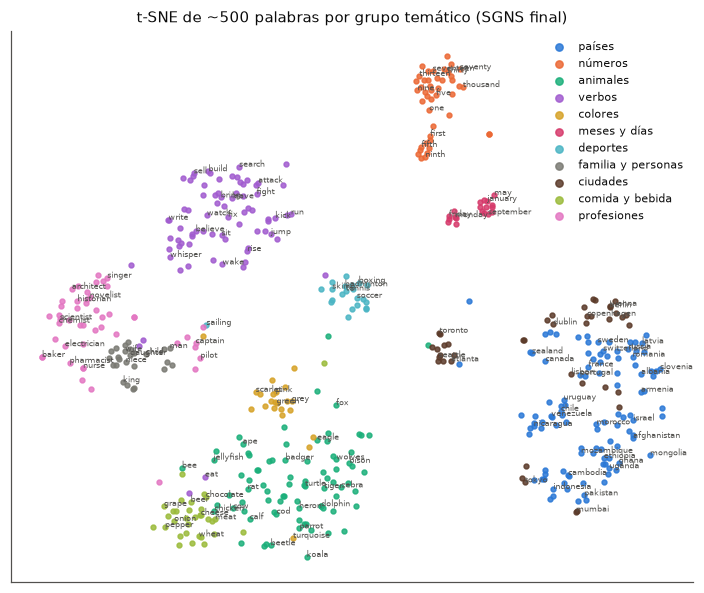

,pureza de 10 vecinos
ciudades,0.67
profesiones,0.72
animales,0.78
colores,0.82
comida y bebida,0.85
verbos,0.88
familia y personas,0.89
deportes,0.92
países,0.95
números,0.97


In [24]:
from sklearn.manifold import TSNE
GRUPOS = {
    "países": "albania serbia croatia bosnia slovenia slovakia bulgaria estonia latvia lithuania belarus georgia armenia azerbaijan kazakhstan uzbekistan mongolia nepal bangladesh myanmar cambodia laos singapore taiwan venezuela ecuador bolivia paraguay uruguay panama guatemala honduras nicaragua haiti tunisia somalia uganda tanzania zimbabwe zambia ghana senegal cameroon angola mozambique madagascar iceland luxembourg france germany italy spain portugal england scotland ireland russia china japan india pakistan iran iraq egypt israel turkey greece poland sweden norway denmark finland canada mexico brazil argentina chile peru colombia australia zealand africa nigeria kenya ethiopia korea vietnam thailand indonesia philippines malaysia austria switzerland belgium netherlands hungary romania ukraine cuba jamaica afghanistan syria lebanon jordan morocco algeria libya sudan".split(),
    "números": "one two three four five six seven eight nine ten eleven twelve thirteen fourteen fifteen sixteen seventeen eighteen nineteen twenty thirty forty fifty sixty seventy eighty ninety hundred thousand million billion dozen first second third fourth fifth sixth seventh eighth ninth tenth half twice".split(),
    "animales": "wolves sparrow pigeon swan heron penguin salmon trout cod octopus crab lobster jellyfish hippopotamus rhinoceros kangaroo koala panda otter beaver badger hedgehog moose buffalo bison mule pony lamb calf dog cat horse cow pig sheep goat chicken duck goose bird eagle hawk owl crow parrot fish shark whale dolphin seal snake lizard turtle frog crocodile lion tiger leopard bear wolf fox deer elephant monkey ape gorilla rabbit mouse rat squirrel bat insect bee ant butterfly spider beetle mosquito camel donkey zebra giraffe".split(),
    "verbos": "talk shout whisper cry laugh smile sit stand lie fall rise grow shrink sleep wake marry divorce arrive leave enter escape hide search steal borrow lend run walk swim fly jump climb throw catch kick push pull carry eat drink sleep sing dance write read speak listen watch see hear think believe know learn teach build destroy create break fix open close buy sell pay give take bring send receive help attack defend win lose fight kill".split(),
    "colores": "red blue green yellow orange purple pink brown black white grey gray violet crimson scarlet golden silver beige turquoise maroon navy indigo".split(),
    "meses y días": "january february march april may june july august september october november december monday tuesday wednesday thursday friday saturday sunday".split(),
    "deportes": "football soccer baseball basketball hockey tennis golf cricket rugby boxing wrestling cycling swimming skiing volleyball athletics racing sailing rowing fencing gymnastics badminton".split(),
    "familia y personas": "mother father son daughter brother sister husband wife uncle aunt nephew niece grandfather grandmother cousin king queen prince princess man woman boy girl child baby".split(),
    "ciudades": "london paris berlin rome madrid moscow tokyo beijing shanghai delhi mumbai cairo istanbul athens vienna prague warsaw budapest dublin edinburgh amsterdam brussels lisbon stockholm oslo helsinki copenhagen chicago boston philadelphia toronto montreal sydney melbourne seattle denver houston dallas atlanta miami detroit".split(),
    "comida y bebida": "bread cheese butter milk egg meat beef pork chicken rice wheat corn potato tomato onion garlic apple orange banana grape lemon sugar salt pepper soup salad wine beer coffee tea juice chocolate cake honey".split(),
    "profesiones": "chef baker carpenter plumber mechanic electrician banker accountant economist historian philosopher mathematician physicist chemist biologist surgeon dentist pharmacist sailor merchant doctor nurse lawyer teacher engineer scientist writer artist musician singer actor soldier officer captain priest bishop farmer pilot judge politician journalist architect painter poet composer novelist professor student".split(),
}
kv_best = kvs["SBEST"]
words, groups = [], []
for g, ws in GRUPOS.items():
    for w in dict.fromkeys(ws):
        if w in kv_best.key_to_index and w not in words:
            words.append(w); groups.append(g)
print(f"{len(words)} palabras en {len(GRUPOS)} grupos")
X = np.stack([kv_best[w] for w in words]); X /= np.linalg.norm(X, axis=1, keepdims=True)
xy = TSNE(n_components=2, perplexity=30, metric="cosine", init="pca", random_state=C.SEED).fit_transform(X)
fig = P.tsne(xy, groups, words); plt.show()
# pureza de vecindario: fracción de los 10 vecinos (en el espacio original) que son del mismo grupo
S_ = X @ X.T; np.fill_diagonal(S_, -1); g_arr = np.array(groups)
nn10 = np.argsort(-S_, axis=1)[:, :10]
purity = pd.Series((g_arr[nn10] == g_arr[:, None]).mean(1), index=g_arr).groupby(level=0).mean().sort_values()
display(purity.rename("pureza de 10 vecinos").to_frame().style.format("{:.2f}"))

**¿Se forman los grupos esperados? Sí.** Los 519 puntos de 11 grupos forman cúmulos claros: meses y días (pureza 0.99, con días y meses como dos subgrupos), números (0.97, con los ordinales `first…ninth` en un subgrupo aparte de los cardinales), países (0.95, que además se separan por región: Europa, Latinoamérica, Asia/África), deportes (0.92), verbos (0.88) y comida (0.85).

Las mezclas tienen sentido semántico:
- **Ciudades (0.67):** quedan junto a sus países (Tokio y Mumbai dentro del cúmulo asiático, Lisboa junto a Portugal), porque una ciudad comparte contextos con su país.
- **Profesiones (0.72):** se mezclan con familia y personas (`king`, `captain`, `pilot`).
- **Animales (0.78):** se mezclan con comida (`chicken`, `cow`, `calf`, `cod`).

### 5.3 Paralelismo de los vectores diferencia

Si la aritmética fuera exacta, todos los vectores diferencia de una relación (p. ej. $\hat{queen}-\hat{king}$, $\hat{woman}-\hat{man}$, ...) serían **paralelos** (coseno 1). Se mide el coseno promedio entre todos los pares de vectores diferencia de cada relación; como referencia, se calcula lo mismo con pares de palabras al azar del top-10k.

In [25]:
RELACIONES = {
    "género": [("man", "woman"), ("king", "queen"), ("boy", "girl"), ("brother", "sister"), ("father", "mother"), ("he", "she"),
               ("son", "daughter"), ("uncle", "aunt"), ("husband", "wife"), ("nephew", "niece"), ("prince", "princess"), ("actor", "actress")],
    "país–capital": [("france", "paris"), ("germany", "berlin"), ("italy", "rome"), ("spain", "madrid"), ("japan", "tokyo"), ("russia", "moscow"),
                     ("china", "beijing"), ("egypt", "cairo"), ("greece", "athens"), ("canada", "ottawa"), ("poland", "warsaw"), ("austria", "vienna")],
    "país–gentilicio": [("france", "french"), ("germany", "german"), ("china", "chinese"), ("japan", "japanese"), ("italy", "italian"), ("spain", "spanish"),
                        ("russia", "russian"), ("mexico", "mexican"), ("brazil", "brazilian"), ("india", "indian"), ("greece", "greek"), ("poland", "polish")],
    "comparativo": [("good", "better"), ("bad", "worse"), ("big", "bigger"), ("small", "smaller"), ("fast", "faster"), ("strong", "stronger"),
                    ("old", "older"), ("young", "younger"), ("high", "higher"), ("low", "lower"), ("long", "longer"), ("short", "shorter")],
    "pasado": [("walk", "walked"), ("go", "went"), ("take", "took"), ("see", "saw"), ("play", "played"), ("write", "wrote"),
               ("run", "ran"), ("give", "gave"), ("eat", "ate"), ("find", "found"), ("make", "made"), ("know", "knew")],
    "plural": [("car", "cars"), ("child", "children"), ("man", "men"), ("city", "cities"), ("country", "countries"), ("dog", "dogs"),
               ("house", "houses"), ("woman", "women"), ("book", "books"), ("song", "songs"), ("year", "years"), ("game", "games")],
}
rng = np.random.default_rng(C.SEED)
top10k = kv_glove.index_to_key[:10_000]
rand_pairs = [tuple(rng.choice([w for w in top10k if w in kv_best.key_to_index], 2, replace=False)) for _ in range(12)]
par = {}
for m, kv in MODELS.items():
    par[m] = {rel: E.offset_parallelism(kv, pairs)[0] for rel, pairs in RELACIONES.items()}
    par[m]["PROMEDIO (6 relaciones)"] = np.mean(list(par[m].values()))
    par[m]["pares al azar (referencia)"] = E.offset_parallelism(kv, rand_pairs)[0]
par = pd.DataFrame(par)
par.to_csv(C.RESULTS_DIR / "paralelismo.csv")
display(par.style.format("{:.3f}").background_gradient(cmap="Greens", vmin=0, vmax=0.6))

,SGNS (propio),Word2Vec gensim,GloVe 6B
género,0.300,0.332,0.586
país–capital,0.376,0.378,0.609
país–gentilicio,0.606,0.614,0.812
comparativo,0.356,0.384,0.403
pasado,0.399,0.375,0.542
plural,0.294,0.277,0.328
PROMEDIO (6 relaciones),0.389,0.393,0.547
pares al azar (referencia),0.013,0.004,0.028


**Paralelismo.** Los vectores diferencia de una misma relación están claramente **correlacionados**: coseno promedio de **0.389** en SGNS, 0.393 en gensim y **0.547** en GloVe, contra ~0.01–0.03 para pares al azar. Pero están **lejos de ser paralelos** (coseno 1). La relación más consistente es país–gentilicio (0.61 SGNS, 0.81 GloVe), y las menos consistentes son plural (0.29) y género (0.30). Coincide con 5.2: las categorías con offsets más paralelos son las que mejor resuelven analogías. GloVe, con 244× más datos, tiene offsets más paralelos que nuestros modelos.

## 6. Pipeline end-to-end: clasificación de AG News

AG News tiene 120,000 noticias de entrenamiento y 7,600 de test en 4 clases balanceadas (World, Sports, Business, Sci/Tech). Cada documento es título + descripción. Se aplica **exactamente la misma normalización y tokenizador** de la sección 2 y se separa el 10 % estratificado del train oficial como validación (108,000 / 12,000); el test oficial solo se usa al final.

In [26]:
data = K.load_ag_news()
for sp in ["train", "val", "test"]:
    toks, y, _ = data[sp]
    lens = np.array([len(t) for t in toks])
    print(f"{sp:5s}: {len(y):,} documentos | clases {np.bincount(y).tolist()} | tokens/doc mediana {np.median(lens):.0f}, p95 {np.percentile(lens, 95):.0f}")
print("\nEjemplo:", data["train"][2][0]); print("Tokens :", data["train"][0][0])

train: 108,000 documentos | clases [27000, 27000, 27000, 27000] | tokens/doc mediana 37, p95 52
val  : 12,000 documentos | clases [3000, 3000, 3000, 3000] | tokens/doc mediana 37, p95 52
test : 7,600 documentos | clases [1900, 1900, 1900, 1900] | tokens/doc mediana 37, p95 52

Ejemplo: 10 seconds that change everything ATHENS - Ten seconds. Barely time enough to tie a shoe, wash a glass, get the paper off the porch. But when the moment comes, and eight men kneel at their blocks and peer down the empty, waiting track, it is as if the entire Olympics stop to watch.
Tokens : ['10', 'seconds', 'that', 'change', 'everything', 'athens', 'ten', 'seconds', 'barely', 'time', 'enough', 'to', 'tie', 'a', 'shoe', 'wash', 'a', 'glass', 'get', 'the', 'paper', 'off', 'the', 'porch', 'but', 'when', 'the', 'moment', 'comes', 'and', 'eight', 'men', 'kneel', 'at', 'their', 'blocks', 'and', 'peer', 'down', 'the', 'empty', 'waiting', 'track', 'it', 'is', 'as', 'if', 'the', 'entire', 'olympics', 'stop', 'to

In [27]:
EMB = {"SGNS": kvs["SBEST"], "gensim": kv_gensim, "GloVe": kv_glove}
all_toks = data["train"][0] + data["val"][0] + data["test"][0]
oov = {m: dict(zip(["% tokens OOV", "% tipos OOV"], K.oov_rate(all_toks, kv.key_to_index))) for m, kv in EMB.items()}
oov = pd.DataFrame(oov).T
display(oov.style.format("{:.2f} %"))
from collections import Counter
cnt = Counter(t for toks in all_toks for t in toks)
for m in ["SGNS", "GloVe"]:
    miss = [(w, n) for w, n in cnt.most_common() if w not in EMB[m].key_to_index][:15]
    print(f"OOV más frecuentes en {m}:", ", ".join(f"{w} ({n})" for w, n in miss))

,% tokens OOV,% tipos OOV
SGNS,3.46 %,48.96 %
gensim,3.46 %,48.96 %
GloVe,0.83 %,23.33 %


OOV más frecuentes en SGNS: afp (4892), peoplesoft (1727), third-quarter (1170), yukos (782), calif (739), fallujah (649), washingtonpost (566), newsfactor (554), 6-4 (470), merck (468), novell (457), vioxx (450), nikkei (421), cingular (412), fla (411)
OOV más frecuentes en GloVe: washingtonpost (566), newsfactor (554), maccentral (223), techweb (150), siliconvalley (146), newratings (140), psft (108), better-than-expected (102), sven-goran (100), same-store (90), p2pnet (89), hd-dvd (77), profit-taking (76), thedeal (74), nbsp (71)


**OOV en AG News.** El **3.46 %** de los tokens de AG News no está en el vocabulario de nuestro SGNS (y de gensim, que comparte vocabulario), contra solo el **0.83 %** de GloVe. Por tipos la diferencia es mayor (49 % contra 23 %). Los OOV de SGNS son **entidades de noticias de 2004** que no aparecen en los primeros artículos de Wikipedia (`afp`, `peoplesoft`, `yukos`, `fallujah`, `vioxx`, `cingular`) y abreviaturas periodísticas (`calif`, `fla`). Los de GloVe son casi solo restos de URLs (`washingtonpost`, `newsfactor`). Es un **cambio de dominio**: GloVe se entrenó también con Gigaword (noticias), justo el dominio de AG News.

### 6.1 Modelos

- **Baseline:** TF-IDF de unigramas + bigramas (mismo tokenizador, `sublinear_tf`, `min_df=2`) + regresión logística; $C \in \{1, 4, 16\}$ elegido en validación.
- **Embeddings aleatorios:** `nn.EmbeddingBag(mode="mean")` → Linear(d, 256) → ReLU → Dropout(0.3) → Linear(256, 4), con la tabla inicializada aleatoriamente ($\mathcal N(0,1)$) y vocabulario del train (`min_count`=2, resto → `<unk>`), d = 100.
- **SGNS / gensim / GloVe:** el mismo clasificador con la tabla inicializada con los embeddings, **(a) congelada** o **(b) con fine-tuning**. El vocabulario son las palabras de AG News que el embedding conoce; los tokens fuera de su vocabulario se mapean a `<pad>`, que `EmbeddingBag` excluye del promedio.

Todos se entrenan con Adam (lr $10^{-3}$), batch 256 y early stopping sobre el F1 macro de validación (paciencia 3, máximo 20 epochs con el 100 % de los datos); se restauran los pesos del mejor epoch.

In [28]:
CLS = {}
CLS["TF-IDF + LogReg"] = K.tfidf_baseline(data)
CLS["Aleatorio (fine-tuning)"] = K.train_classifier(data, "random", dim=100)
for m, kv in EMB.items():
    CLS[f"{m} congelado"] = K.train_classifier(data, "pretrained", kv=kv, freeze=True)
    CLS[f"{m} fine-tuning"] = K.train_classifier(data, "pretrained", kv=kv, freeze=False)

def cls_row(name, r):
    return {"modelo": name, **{f"val {k}": v for k, v in r["best"].items() if k != "epoch"},
            "mejor epoch": r["best"].get("epoch", "—"), "epochs": len(r.get("history", [])) or "—",
            "vocab": r["vocab"], "parámetros totales": r["params_total"], "entrenables": r["params_trainable"],
            "tiempo (s)": r["train_time_s"]}
cls_tab = pd.DataFrame([cls_row(n, r) for n, r in CLS.items()]).set_index("modelo")
cls_tab.to_csv(C.RESULTS_DIR / "clasificacion_validacion.csv")
display(cls_tab.style.format({"val acc": "{:.4f}", "val precision": "{:.4f}", "val recall": "{:.4f}", "val f1": "{:.4f}",
        "vocab": "{:,}", "parámetros totales": "{:,}", "entrenables": "{:,}", "tiempo (s)": "{:.1f}"})
        .background_gradient(subset=["val f1"], cmap="Greens"))

,val acc,val precision,val recall,val f1,mejor epoch,epochs,vocab,parámetros totales,entrenables,tiempo (s)
modelo,,,,,,,,,,
TF-IDF + LogReg,0.9241,0.9239,0.9241,0.9239,—,—,"423,058","1,692,236","1,692,236",43.2
Aleatorio (fine-tuning),0.9127,0.9127,0.9127,0.9125,7,10,"49,084","4,935,284","4,935,284",16.0
SGNS congelado,0.8922,0.8925,0.8922,0.8919,19,20,"43,704","4,397,284","26,884",11.8
SGNS fine-tuning,0.9164,0.9168,0.9164,0.9162,2,5,"43,704","4,397,284","4,397,284",7.5
gensim congelado,0.8928,0.8932,0.8928,0.8927,18,20,"43,704","4,397,284","26,884",11.7
gensim fine-tuning,0.9172,0.9173,0.9172,0.9170,3,6,"43,704","4,397,284","4,397,284",9.0
GloVe congelado,0.9078,0.9080,0.9078,0.9077,19,20,"65,647","6,591,584","26,884",11.9
GloVe fine-tuning,0.9229,0.9230,0.9229,0.9227,3,6,"65,647","6,591,584","6,591,584",12.1


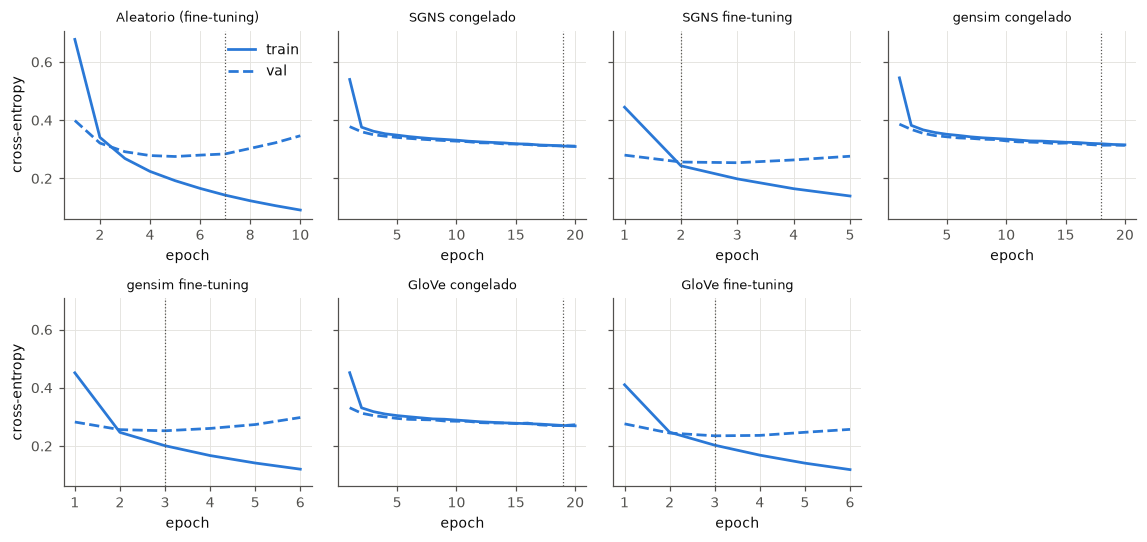

In [29]:
P.classifier_curves({n: r for n, r in CLS.items() if "history" in r}); plt.show()

**Validación.** El mejor modelo es el **baseline TF-IDF + LogReg (F1 0.924)**, seguido de **GloVe con fine-tuning (0.923)**, gensim y SGNS con fine-tuning (0.917 y 0.916) y los embeddings aleatorios (0.913). Las variantes **congeladas** quedan por debajo (GloVe 0.908, SGNS/gensim 0.892), pero entrenan solo **26,884 parámetros** (el MLP) contra 4.4–6.6M. Con fine-tuning, los modelos con embeddings sobreajustan rápido: la pérdida de validación sube desde el epoch 2–3 mientras la de entrenamiento sigue bajando. Ahí actúa el early stopping. Los congelados no sobreajustan, pero convergen lento y siguen mejorando al llegar al tope de 20 epochs. Todos entrenan en 7–16 s en CPU (TF-IDF tarda 43 s porque prueba 3 valores de C).

### 6.2 Evaluación final en test

Se evalúa **una sola vez** sobre el test oficial la mejor variante (según F1 de validación) de cada inicialización.

,acc,precision,recall,f1
TF-IDF + LogReg,0.9212,0.9211,0.9212,0.9210
Aleatorio (fine-tuning),0.9045,0.9044,0.9045,0.9043
SGNS fine-tuning,0.9113,0.9118,0.9113,0.9112
gensim fine-tuning,0.9136,0.9136,0.9136,0.9134
GloVe fine-tuning,0.9167,0.9166,0.9167,0.9165


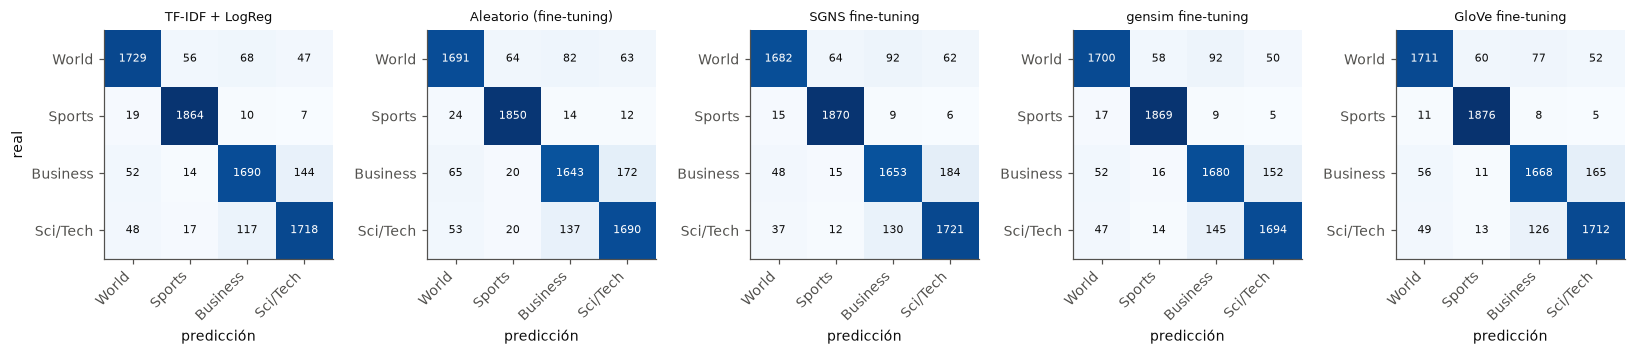

In [30]:
best_variant = {"TF-IDF": "TF-IDF + LogReg", "Aleatorio": "Aleatorio (fine-tuning)"}
for m in EMB:
    best_variant[m] = max([f"{m} congelado", f"{m} fine-tuning"], key=lambda n: CLS[n]["best"]["f1"])
TEST = {}
for init, name in best_variant.items():
    TEST[name] = K.tfidf_test(CLS[name], data) if init == "TF-IDF" else K.evaluate_test(CLS[name], data)
test_tab = pd.DataFrame({n: {k: v for k, v in r.items() if k != "cm"} for n, r in TEST.items()}).T
test_tab.to_csv(C.RESULTS_DIR / "clasificacion_test.csv")
display(test_tab.style.format("{:.4f}"))
fig = P.confusion_matrices([TEST[n]["cm"] for n in TEST], list(TEST)); plt.show()

**Test (una sola evaluación por inicialización; en todas, la mejor variante fue fine-tuning):** TF-IDF **0.921**, GloVe 0.917, gensim 0.913, SGNS 0.911 y aleatorio 0.904. El orden es el mismo que en validación y las diferencias son pequeñas (<1.7 puntos). En las cinco matrices de confusión **Sports** es la clase más fácil (~98 % de recall) y la confusión principal es **Business ↔ Sci/Tech** (117–184 errores en cada dirección: noticias de empresas tecnológicas como *PeopleSoft* u *Oracle* son ambas cosas), seguida de World → Business.

### 6.3 SimLex-999

SimLex-999 mide **similitud** estricta (p. ej. `coast`–`shore` alto, pero `car`–`tire` bajo aunque estén relacionadas), a diferencia de WordSim-353, que mezcla similitud y asociación. Es la evaluación final reservada: no se usó para elegir configuraciones.

In [31]:
sims = {m: {"WordSim-353 ρ": E.word_pairs(kv, E.WORDSIM)["spearman"], "SimLex-999 ρ": E.word_pairs(kv, E.SIMLEX)["spearman"],
            "SimLex OOV %": E.word_pairs(kv, E.SIMLEX)["oov_%"]} for m, kv in MODELS.items()}
sims = pd.DataFrame(sims).T
display(sims.style.format({"WordSim-353 ρ": "{:.3f}", "SimLex-999 ρ": "{:.3f}", "SimLex OOV %": "{:.1f}"}))

,WordSim-353 ρ,SimLex-999 ρ,SimLex OOV %
SGNS (propio),0.664,0.262,0.4
Word2Vec gensim,0.672,0.311,0.4
GloVe 6B,0.533,0.298,0.0


**SimLex-999** es mucho más difícil que WordSim para los tres modelos: SGNS **0.262**, gensim **0.311**, GloVe **0.298**. Los embeddings distribucionales aprenden *asociación* (palabras que aparecen juntas o en contextos parecidos), y SimLex penaliza justo eso: antónimos como `old`–`new` o pares relacionados pero no similares tienen puntaje humano bajo y coseno alto. Nuestro SGNS queda un poco por debajo de gensim; una explicación posible es que nuestro modelo es más «temático» (mejor en analogías semánticas y en WordSim, que premia la asociación) y gensim algo más «sintáctico».

### 6.4 Cantidad de datos: 1 %, 10 %, 50 % y 100 % del train

Mismo protocolo (validación completa de 12,000 para early stopping, submuestra estratificada del train). Con pocos datos se permiten más epochs (≈3,000 pasos como mínimo, hasta 100 epochs). Este experimento evalúa en test cada punto para construir la gráfica de la sección 7.

In [32]:
FRACS = [0.01, 0.10, 0.50, 1.0]
frac_path = C.RESULTS_DIR / "f1_vs_fraccion.csv"
VARIANTS = [("TF-IDF", None, None), ("Aleatorio", "random", False)] + \
           [(f"{m} {v}", "pretrained", v == "congelado") for m in ["SGNS", "GloVe"] for v in ["congelado", "fine-tuning"]]
rows = []
for frac in FRACS:
    for name, init, freeze in VARIANTS:
        if frac == 1.0:   # ya entrenados en 6.1
            key = {"TF-IDF": "TF-IDF + LogReg", "Aleatorio": "Aleatorio (fine-tuning)"}.get(name, name)
            r = CLS[key]
        elif name == "TF-IDF":
            r = K.tfidf_baseline(data, frac=frac)
        else:
            kv = EMB[name.split()[0]] if init == "pretrained" else None
            r = K.train_classifier(data, init, kv=kv, freeze=freeze, frac=frac)
        te = K.tfidf_test(r, data) if name == "TF-IDF" else K.evaluate_test(r, data)
        rows.append({"modelo": name, "frac": frac, "n_train": r["n_train"], "f1_val": r["best"]["f1"], "f1_test": te["f1"], "acc_test": te["acc"]})
fr = pd.DataFrame(rows)
fr.to_csv(frac_path, index=False)
display(fr.pivot(index="modelo", columns="frac", values="f1_test").loc[[v[0] for v in VARIANTS]].style.format("{:.4f}")
        .background_gradient(axis=0, cmap="Greens").set_caption("F1 macro de test por fracción de datos"))

frac,0.010000,0.100000,0.500000,1.000000
modelo,,,,
TF-IDF,0.8250,0.8870,0.9082,0.9210
Aleatorio,0.7392,0.8477,0.8930,0.9043
SGNS congelado,0.8587,0.8757,0.8839,0.8897
SGNS fine-tuning,0.8599,0.8917,0.9019,0.9112
GloVe congelado,0.8710,0.8888,0.8917,0.9009
GloVe fine-tuning,0.8728,0.8957,0.9113,0.9165
